<center><h2><span style="font-weight:bolder; color: red; font-size:120%",>A Comparative Analysis of Machine Learning Regression Models for Smartphone Price Prediction with Optuna Hyperparameter Optimization and Streamlit Deployment</span></h2></center>

<div style="
  text-align:center;
  background: linear-gradient(135deg, #000000, #1a1a1a);
  border:2px solid #ff0800ff;
  border-radius:18px;
  padding:25px;
  box-shadow:0 0 25px rgba(255,215,0,0.3);
  transition:all 0.4s ease;
">
  <img src="image.png"
       width="680"
       style="
         border-radius:15px;
         box-shadow:0 0 35px rgba(255,215,0,0.4);
         transition: transform 0.4s ease, box-shadow 0.4s ease;
       "
       onmouseover="this.style.transform='scale(1.0)'; this.style.boxShadow='0 0 50px rgba(255,215,0,0.9)';"
       onmouseout="this.style.transform='scale(1.0)'; this.style.boxShadow='0 0 30px rgba(255,215,0,0.4)';"
  >
  <p style="
     color:#FFD700;
     font-size:20px;
     font-family:'Poppins', sans-serif;
     font-weight:600;
     margin-top:12px;
     letter-spacing:1px;
     text-shadow:0 0 10px rgba(255,215,0,0.8);
  ">
  </p>
</div>


<a id="read"></a>
# <p style="background-color:maroon; font-family:calibri; font-size:80%; color:white; text-align:center; border-radius:15px 50px; padding:10px">Step 1 | Import Libraries</p>

In [1]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import colors
import matplotlib.pyplot as plt
import plotly.graph_objs as go
from plotly.subplots import make_subplots

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from catboost import CatBoostRegressor
from sklearn.svm import SVR
import lightgbm as lgb
import xgboost as xgb

from sklearn.linear_model import ElasticNet
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.kernel_ridge import KernelRidge

from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import HuberRegressor
import pickle

import optuna

<a id="read"></a>
# <p style="background-color:maroon; font-family:calibri; font-size:80%; color:white; text-align:center; border-radius:15px 50px; padding:10px">Step 2 | Introduction</p>

____
<a id="num_univariate"></a>
# <b><span style='color:orangered'>Step 2.1 |</span><span style='color:maroon'> Introduction</span></b>  

<div
  style="border-radius:10px; border:#8B0000 solid; padding:15px; background-color:#FAF3F3; font-size:100%; text-align:left; color:#222;">
  <h3 align="left" style="color:#8B0000;">Introduction</h3>
  <p style="margin:6px 0 0; line-height:1.6;"> This project focuses on
    <strong>predicting the price of mobile phones</strong> using various <strong>Machine Learning algorithms</strong>.
    The dataset used in this project contains multiple features of different smartphones such as <em>RAM</em>,
    <em>Battery Capacity</em>, <em>Processor Type</em>, <em>Screen Size</em>, and other hardware specifications, along
    with their respective <strong>target prices</strong>. The primary goal of this project is to build a strong
    <strong>regression model</strong> that can accurately predict the <strong>mobile price</strong> based on the given
    features. By analyzing the relationship between these technical attributes and the price, this project aims to help
    users and manufacturers understand how different specifications affect the overall market price of a smartphone.
  </p>
</div>

____
<a id="num_univariate"></a>
# <b><span style='color:orangered'>Step 2.2 |</span><span style='color:maroon'> About the dataset and its features</span></b>  

<div
    style="border-radius:10px; border:#8B0000 solid; padding:10px; background-color:#FAF3F3; font-size:100%; text-align:left; color:#222;">
    Used dataset: <a href="https://www.kaggle.com/datasets/abdurrahman22224/smartphone-new-data" target="_blank">Click here for the Mobile Price Prediction dataset (Kaggle)</a>
</div>

<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <title>Smartphone Dataset Attributes</title>
  <style>
    /* CSS Custom Properties for theming */
    :root {
      --bg-color: #ffffff;
      --container-bg-color: #FAF3F3;
      --text-color: #222222;
      --primary-color: #8B0000;
      --container-border-color: #8B0000;
      --table-border-color: #e0c5c5;
      --header-bg-color: #F5D7D7;
      --row-hover-bg-color: #EFEFEF;
      --shadow-color: rgba(0, 0, 0, 0.05);
    }

    @media (prefers-color-scheme: dark) {
      :root {
        --bg-color: #121212;
        --container-bg-color: #2a2a2a;
        --text-color: #e0e0e0;
        --primary-color: #ff8a80;
        --container-border-color: #ff8a80;
        --table-border-color: #444444;
        --header-bg-color: #333333;
        --row-hover-bg-color: #3a3a3a;
        --shadow-color: rgba(0, 0, 0, 0.2);
      }
    }

    * {
      box-sizing: border-box;
    }

    body {
      font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, Helvetica, Arial, sans-serif;
      background-color: var(--bg-color);
      color: var(--text-color);
      margin: 0;
      padding: 1rem;
      line-height: 1.6;
      transition: background-color 0.3s, color 0.3s;
    }

    .container {
      border-radius: 12px;
      border: 2px solid var(--container-border-color);
      padding: 1.5rem;
      background-color: var(--container-bg-color);
      max-width: 1200px;
      margin: 2rem auto;
      box-shadow: 0 4px 12px var(--shadow-color);
    }

    h3 {
      text-align: center;
      color: var(--primary-color);
      margin-top: 0;
      font-size: 1.75rem;
    }

    .table-wrapper {
      overflow-x: auto; /* Enables horizontal scrolling on small screens */
    }

    table {
      width: 100%;
      border-collapse: collapse;
      font-size: 1rem;
      text-align: left;
    }

    th, td {
      padding: 12px 15px;
      border-bottom: 1px solid var(--table-border-color);
      white-space: nowrap; /* Prevents content from wrapping */
    }

    td:nth-child(3) {
      white-space: normal; /* Allow description to wrap */
    }

    thead {
      background-color: var(--header-bg-color);
    }

    th {
      font-weight: 600;
      border-bottom: 2px solid var(--primary-color);
    }

    tbody tr {
      transition: background-color 0.2s;
    }

    tbody tr:hover {
      background-color: var(--row-hover-bg-color);
    }

  </style>
</head>
<body>
  <div class="container">
    <h3>Smartphone Dataset Attributes</h3>
    <div class="table-wrapper">
      <table>
        <thead>
          <tr>
            <th>No.</th>
            <th>Attribute</th>
            <th>Feature Description</th>
            <th>Type</th>
          </tr>
        </thead>
        <tbody>
          <tr>
            <td>1</td>
            <td>brand_name</td>
            <td>Brand name of the smartphone</td>
            <td>Categorical</td>
          </tr>
          <tr>
            <td>2</td>
            <td>model</td>
            <td>Model name of the smartphone</td>
            <td>Categorical</td>
          </tr>
          <tr>
            <td>3</td>
            <td>rating</td>
            <td>Average user rating (out of 5)</td>
            <td>Numeric</td>
          </tr>
          <tr>
            <td>4</td>
            <td>has_5g</td>
            <td>Indicates if 5G connectivity is supported (1=True, 0=False)</td>
            <td>Boolean</td>
          </tr>
          <tr>
            <td>5</td>
            <td>has_nfc</td>
            <td>Indicates if NFC is supported (1=True, 0=False)</td>
            <td>Boolean</td>
          </tr>
          <tr>
            <td>6</td>
            <td>has_ir_blaster</td>
            <td>Indicates if IR Blaster is available</td>
            <td>Boolean</td>
          </tr>
          <tr>
            <td>7</td>
            <td>processor_brand</td>
            <td>Brand of processor (e.g., Qualcomm, MediaTek, Exynos)</td>
            <td>Categorical</td>
          </tr>
          <tr>
            <td>8</td>
            <td>num_cores</td>
            <td>Number of processor cores</td>
            <td>Numeric</td>
          </tr>
          <tr>
            <td>9</td>
            <td>processor_speed</td>
            <td>Processor clock speed (in GHz)</td>
            <td>Numeric</td>
          </tr>
          <tr>
            <td>10</td>
            <td>battery_capacity</td>
            <td>Total battery capacity (in mAh)</td>
            <td>Numeric</td>
          </tr>
          <tr>
            <td>11</td>
            <td>fast_charging</td>
            <td>Fast charging power (in Watts)</td>
            <td>Numeric</td>
          </tr>
          <tr>
            <td>12</td>
            <td>ram_capacity</td>
            <td>RAM size (in GB)</td>
            <td>Numeric</td>
          </tr>
          <tr>
            <td>13</td>
            <td>internal_memory</td>
            <td>Internal storage capacity (in GB)</td>
            <td>Numeric</td>
          </tr>
          <tr>
            <td>14</td>
            <td>screen_size</td>
            <td>Screen size (in inches)</td>
            <td>Numeric</td>
          </tr>
          <tr>
            <td>15</td>
            <td>refresh_rate</td>
            <td>Display refresh rate (in Hz)</td>
            <td>Numeric</td>
          </tr>
          <tr>
            <td>16</td>
            <td>resolution</td>
            <td>Display resolution (e.g., 2400×1080)</td>
            <td>Categorical</td>
          </tr>
          <tr>
            <td>17</td>
            <td>num_rear_cameras</td>
            <td>Number of rear cameras</td>
            <td>Numeric</td>
          </tr>
          <tr>
            <td>18</td>
            <td>num_front_cameras</td>
            <td>Number of front cameras</td>
            <td>Numeric</td>
          </tr>
          <tr>
            <td>19</td>
            <td>os</td>
            <td>Operating system (Android / iOS)</td>
            <td>Categorical</td>
          </tr>
          <tr>
            <td>20</td>
            <td>primary_camera_rear</td>
            <td>Main rear camera resolution (in Megapixels)</td>
            <td>Numeric</td>
          </tr>
          <tr>
            <td>21</td>
            <td>primary_camera_front</td>
            <td>Main front camera resolution (in Megapixels)</td>
            <td>Numeric</td>
          </tr>
          <tr>
            <td>22</td>
            <td>extended_memory_available</td>
            <td>Indicates if expandable memory slot is available</td>
            <td>Boolean</td>
          </tr>
          <tr>
            <td>23</td>
            <td>extended_upto</td>
            <td>Maximum expandable storage supported (in GB/TB)</td>
            <td>Numeric</td>
          </tr>
          <tr>
            <td>24</td>
            <td>price</td>
            <td>Price of the smartphone (Target Variable)</td>
            <td>Numeric</td>
          </tr>
        </tbody>
      </table>
    </div>
  </div>
</body>
</html>


<div
  style="border-radius:10px; border:#8B0000 solid; padding:15px; background-color:#FAF3F3; font-size:100%; text-align:left; color:#222;">
  <h3 align="left" style="color:#8B0000;">Dataset Information</h3>
  <ul style="list-style-type:none; padding-left:0; line-height:1.6;">
    <li>
      <strong>This dataset contains 987 rows, with details about 25 features.</strong>
    </li>
    <li>
      <strong>There are some empty or NaN and duplicates values in this dataset.</strong>
    </li>
  </ul>
</div>

<a id="read"></a>
# <p style="background-color:maroon; font-family:calibri; font-size:80%; color:white; text-align:center; border-radius:15px 50px; padding:10px">Step 3 | Data Collection</p>

____
<a id="num_univariate"></a>
# <b><span style='color:orangered'>Step 3.1 |</span><span style='color:maroon'> Load DataSet</span></b>  

In [2]:
# Load the dataset from current directory
df = pd.read_csv("smartphone.csv")
df.head(3) # Display the first 3 rows of the dataframe

,brand_name,model,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,battery_capacity,...,refresh_rate,resolution,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto,price
0,oneplus,OnePlus 11 5G,89.0,True,True,False,snapdragon,8.0,3.2,5000.0,...,120,1440 x 3216,3,1.0,android,50.0,16.0,0,NaN,54999.0
1,oneplus,OnePlus Nord CE 2 Lite 5G,81.0,True,False,False,snapdragon,8.0,2.2,5000.0,...,120,1080 x 2412,3,1.0,android,64.0,16.0,1,1024.0,19989.0
2,samsung,Samsung Galaxy A14 5G,75.0,True,False,False,exynos,8.0,2.4,5000.0,...,90,1080 x 2408,3,1.0,android,50.0,13.0,1,1024.0,16499.0


<a id="read"></a>
# <p style="background-color:maroon; font-family:calibri; font-size:80%; color:white; text-align:center; border-radius:15px 50px; padding:10px">Step 4 | Data Preprocessing</p>

In [3]:
df.head(3) # Display the last 3 rows of the dataframe

,brand_name,model,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,battery_capacity,...,refresh_rate,resolution,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto,price
0,oneplus,OnePlus 11 5G,89.0,True,True,False,snapdragon,8.0,3.2,5000.0,...,120,1440 x 3216,3,1.0,android,50.0,16.0,0,NaN,54999.0
1,oneplus,OnePlus Nord CE 2 Lite 5G,81.0,True,False,False,snapdragon,8.0,2.2,5000.0,...,120,1080 x 2412,3,1.0,android,64.0,16.0,1,1024.0,19989.0
2,samsung,Samsung Galaxy A14 5G,75.0,True,False,False,exynos,8.0,2.4,5000.0,...,90,1080 x 2408,3,1.0,android,50.0,13.0,1,1024.0,16499.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 987 entries, 0 to 986
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   brand_name                 987 non-null    str    
 1   model                      987 non-null    str    
 2   rating                     885 non-null    float64
 3   has_5g                     987 non-null    bool   
 4   has_nfc                    987 non-null    bool   
 5   has_ir_blaster             987 non-null    bool   
 6   processor_brand            967 non-null    str    
 7   num_cores                  981 non-null    float64
 8   processor_speed            945 non-null    float64
 9   battery_capacity           975 non-null    float64
 10  fast_charging_available    775 non-null    float64
 11  fast_charging              775 non-null    float64
 12  ram_capacity               986 non-null    float64
 13  internal_memory            987 non-null    int64  
 14  scree

In [5]:
df.describe()

,rating,num_cores,processor_speed,battery_capacity,fast_charging_available,fast_charging,ram_capacity,internal_memory,screen_size,refresh_rate,num_rear_cameras,num_front_cameras,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto,price
count,885.000000,981.000000,945.000000,975.000000,775.000000,775.000000,986.000000,987.000000,987.000000,987.000000,987.000000,983.000000,987.000000,982.000000,987.000000,503.000000,986.000000
mean,78.273446,7.771662,2.427778,4815.648205,46.078710,46.078710,6.562880,141.138804,6.537761,92.270517,2.815603,1.031536,50.456839,16.597149,0.629179,736.254473,32613.674442
std,7.386228,0.835960,0.464432,1007.961110,34.304387,34.304387,2.743262,106.910362,0.350156,28.962114,0.776453,0.174850,33.255229,10.900773,0.483269,366.874338,39638.505052
min,60.000000,4.000000,1.200000,1821.000000,10.000000,10.000000,1.000000,8.000000,3.540000,60.000000,1.000000,1.000000,2.000000,0.300000,0.000000,32.000000,0.000000
25%,74.000000,8.000000,2.050000,4500.000000,18.000000,18.000000,4.000000,64.000000,6.500000,60.000000,2.000000,1.000000,32.000000,8.000000,0.000000,512.000000,12999.000000
50%,80.000000,8.000000,2.300000,5000.000000,33.000000,33.000000,6.000000,128.000000,6.580000,90.000000,3.000000,1.000000,50.000000,16.000000,1.000000,1024.000000,19999.000000
75%,84.000000,8.000000,2.840000,5000.000000,66.000000,66.000000,8.000000,128.000000,6.670000,120.000000,3.000000,1.000000,64.000000,16.000000,1.000000,1024.000000,35496.500000
max,89.000000,8.000000,3.220000,22000.000000,240.000000,240.000000,18.000000,1024.000000,8.030000,240.000000,4.000000,2.000000,200.000000,60.000000,1.000000,2048.000000,650000.000000


In [6]:
df.duplicated().sum()

np.int64(3)

____
<a id="num_univariate"></a>
# <b><span style='color:orangered'>Step 4.1 |</span><span style='color:maroon'> Data Cleaning</span></b>  

### <a id="num_univariate_1"></a>
#### <b><span style='color:darkorange'>Step 4.1.1 |</span><span style='color:teal'> Handle Missing Values</span></b>

In [7]:
df.isnull().sum()

brand_name                     0
model                          0
rating                       102
has_5g                         0
has_nfc                        0
has_ir_blaster                 0
processor_brand               20
num_cores                      6
processor_speed               42
battery_capacity              12
fast_charging_available      212
fast_charging                212
ram_capacity                   1
internal_memory                0
screen_size                    0
refresh_rate                   0
resolution                     0
num_rear_cameras               0
num_front_cameras              4
os                            14
primary_camera_rear            0
primary_camera_front           5
extended_memory_available      0
extended_upto                484
price                          1
dtype: int64

In [8]:
df[['rating', 'fast_charging', 'extended_upto']] = df[['rating', 'fast_charging', 'extended_upto']].fillna(df[['rating', 'fast_charging', 'extended_upto']].mean())

In [9]:
df.isnull().sum()

brand_name                     0
model                          0
rating                         0
has_5g                         0
has_nfc                        0
has_ir_blaster                 0
processor_brand               20
num_cores                      6
processor_speed               42
battery_capacity              12
fast_charging_available      212
fast_charging                  0
ram_capacity                   1
internal_memory                0
screen_size                    0
refresh_rate                   0
resolution                     0
num_rear_cameras               0
num_front_cameras              4
os                            14
primary_camera_rear            0
primary_camera_front           5
extended_memory_available      0
extended_upto                  0
price                          1
dtype: int64

In [10]:
df.dropna(inplace=True)
df.isnull().sum()

brand_name                   0
model                        0
rating                       0
has_5g                       0
has_nfc                      0
has_ir_blaster               0
processor_brand              0
num_cores                    0
processor_speed              0
battery_capacity             0
fast_charging_available      0
fast_charging                0
ram_capacity                 0
internal_memory              0
screen_size                  0
refresh_rate                 0
resolution                   0
num_rear_cameras             0
num_front_cameras            0
os                           0
primary_camera_rear          0
primary_camera_front         0
extended_memory_available    0
extended_upto                0
price                        0
dtype: int64

### <a id="num_univariate_2"></a>
#### <b><span style='color:darkorange'>Step 4.1.2 |</span><span style='color:teal'> Remove Duplicates</span></b>


In [11]:
df.duplicated().sum()

np.int64(2)

In [12]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

### <a id="num_univariate_3"></a>
#### <b><span style='color:darkorange'>Step 4.1.3 |</span><span style='color:teal'> Data Type Conversion</span></b>



In [13]:
df.info()

<class 'pandas.DataFrame'>
Index: 736 entries, 0 to 986
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   brand_name                 736 non-null    str    
 1   model                      736 non-null    str    
 2   rating                     736 non-null    float64
 3   has_5g                     736 non-null    bool   
 4   has_nfc                    736 non-null    bool   
 5   has_ir_blaster             736 non-null    bool   
 6   processor_brand            736 non-null    str    
 7   num_cores                  736 non-null    float64
 8   processor_speed            736 non-null    float64
 9   battery_capacity           736 non-null    float64
 10  fast_charging_available    736 non-null    float64
 11  fast_charging              736 non-null    float64
 12  ram_capacity               736 non-null    float64
 13  internal_memory            736 non-null    int64  
 14  screen_siz

In [14]:
# Check memory before optimization
print("Memory usage before optimization:")
print(df.info(memory_usage='deep')) # memory usage: 354.8 KB


# Convert selected numeric columns to float16
cols1 = [
    'num_cores', 'processor_speed', 'fast_charging', 
    'screen_size', 'refresh_rate', 'num_rear_cameras'
]

# Convert data types
df[cols1] = df[cols1].astype('float16')

# Convert selected numeric columns to float16
cols2 = [
    'rating', 'num_cores', 'battery_capacity', 
    'ram_capacity', 'internal_memory', 'extended_upto',
    'num_rear_cameras', 'num_front_cameras', 'primary_camera_rear', 'primary_camera_front'
]

# Convert data types
df[cols2] = df[cols2].astype('int16')

# Check memory after optimization
print("\nMemory usage after optimization:")
print(df.info(memory_usage='deep')) # memory usage: 294.4 KB

Memory usage before optimization:
<class 'pandas.DataFrame'>
Index: 736 entries, 0 to 986
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   brand_name                 736 non-null    str    
 1   model                      736 non-null    str    
 2   rating                     736 non-null    float64
 3   has_5g                     736 non-null    bool   
 4   has_nfc                    736 non-null    bool   
 5   has_ir_blaster             736 non-null    bool   
 6   processor_brand            736 non-null    str    
 7   num_cores                  736 non-null    float64
 8   processor_speed            736 non-null    float64
 9   battery_capacity           736 non-null    float64
 10  fast_charging_available    736 non-null    float64
 11  fast_charging              736 non-null    float64
 12  ram_capacity               736 non-null    float64
 13  internal_memory            736 n

____
<a id="num_univariate"></a>
# <b><span style='color:orangered'>Step 4.2 |</span><span style='color:maroon'> Outliers Detection</span></b>  

In [15]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=['float16' ,'float64','int16' ,'int64']).columns

outliers_dict = {}

# Detect outliers using IQR
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # Get outlier rows
    outlier_rows = df[(df[col] < lower) | (df[col] > upper)]
    
    if not outlier_rows.empty:
        outliers_dict[col] = outlier_rows

# Display summary
for col, rows in outliers_dict.items():
    print(f"⚠️ Outliers in '{col}': {len(rows)} rows")


⚠️ Outliers in 'rating': 25 rows
⚠️ Outliers in 'num_cores': 10 rows
⚠️ Outliers in 'battery_capacity': 66 rows
⚠️ Outliers in 'fast_charging_available': 13 rows
⚠️ Outliers in 'fast_charging': 13 rows
⚠️ Outliers in 'ram_capacity': 92 rows
⚠️ Outliers in 'internal_memory': 292 rows
⚠️ Outliers in 'screen_size': 31 rows
⚠️ Outliers in 'num_rear_cameras': 269 rows
⚠️ Outliers in 'num_front_cameras': 26 rows
⚠️ Outliers in 'primary_camera_rear': 171 rows
⚠️ Outliers in 'primary_camera_front': 37 rows
⚠️ Outliers in 'extended_upto': 65 rows
⚠️ Outliers in 'price': 60 rows


### <a id="num_univariate_4"></a>
#### <b><span style='color:darkorange'>Step 4.2.1 |</span><span style='color:teal'> Outlier Detection for 'rating'</span></b>

In [16]:
# Calculate IQR for 'rating' column
q125 = df['rating'].quantile(0.25)
q375 = df['rating'].quantile(0.75)
print(f"Q1 (25th percentile): {q125}")
print(f"Q3 (75th percentile): {q375}")
iqr = q375 - q125
print(f"IQR (Interquartile Range): {iqr}")

# Identify outlier rows in 'rating' column
outlier_rows = df[(df['rating'] < (q125 - 1.5 * iqr)) | (df['rating'] > (q375 + 1.5 * iqr))]
outlier_rows


Q1 (25th percentile): 77.0
Q3 (75th percentile): 84.0
IQR (Interquartile Range): 7.0


/home/vscode/.local/lib/python3.11/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,brand_name,model,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,battery_capacity,...,refresh_rate,resolution,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto,price
16,vivo,Vivo Y16,65,False,False,False,helio,8,2.300781,5000,...,60.0,720 x 1600,2,1,android,13,5,1,736,9999.0
52,jio,Jio JioPhone 5G,64,True,False,False,snapdragon,8,2.199219,5000,...,90.0,720 x 1600,1,1,android,13,8,1,512,11990.0
181,tecno,Tecno Spark Go 2023,62,False,False,False,helio,4,2.000000,5000,...,60.0,720 x 1600,2,1,android,13,5,1,256,6999.0
188,leeco,LeEco S1 Pro,65,False,False,False,tiger,4,1.799805,5000,...,60.0,720 x 1600,2,1,android,13,5,0,736,10999.0
198,samsung,Samsung Galaxy M04,66,False,False,False,helio,8,2.300781,5000,...,60.0,720 x 1600,2,1,android,13,5,1,1024,8499.0
236,vivo,Vivo Y16 (3GB RAM + 64GB),66,False,False,False,helio,8,2.300781,5000,...,60.0,720 x 1600,2,1,android,13,5,1,736,10499.0
298,vivo,Vivo Y01A,60,False,False,False,helio,8,2.300781,5000,...,60.0,720 x 1600,1,1,android,8,5,1,736,7790.0
349,xiaomi,Xiaomi Redmi 9i Sport,66,False,False,False,helio,8,2.000000,5000,...,60.0,720 x 1600,1,1,android,13,5,1,512,7499.0
379,vivo,Vivo Y02s,61,False,False,False,helio,8,2.300781,5000,...,60.0,720 x 1600,1,1,android,8,5,1,736,8990.0
409,samsung,Samsung Galaxy A03,66,False,False,False,unisoc,8,1.599609,5000,...,60.0,720 x 1560,2,1,android,48,5,1,1024,7249.0


<Axes: xlabel='rating'>

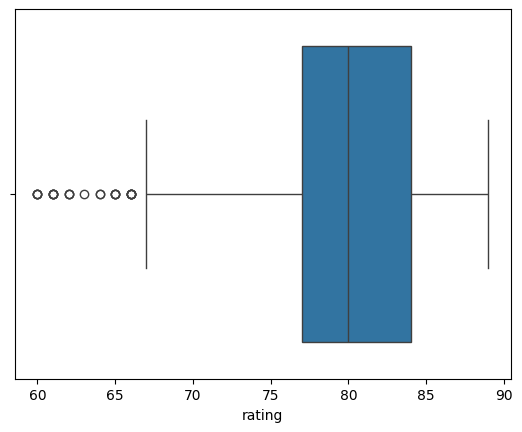

In [17]:
sns.boxplot(x=df['rating'])

In [18]:
# Remove outliers from 'rating' column

# Identify non-outlier rows
nonoutlier_rows = df[(df['rating'] >= (q125 - 1.5 * iqr)) & (df['rating'] <= (q375 + 1.5 * iqr))]

# Display non-outlier rows max() and min()
print('Max rating before outlier removal: ' ,nonoutlier_rows['rating'].max())
print('Min rating before outlier removal: ' ,nonoutlier_rows['rating'].min())

# Cap (Capping: Replace extreme (outlier) values with a fixed limit.) the outliers in 'rating' column with '67.0'
df['rating'] =df['rating'].where( df['rating'] > 67.0, 67.0)

# Display non-outlier rows
print('\nAfter outliers removal: ' ,df[df['rating']< 67.0]) # No outliers should be present now

Max rating before outlier removal:  89
Min rating before outlier removal:  67

After outliers removal:  Empty DataFrame
Columns: [brand_name, model, rating, has_5g, has_nfc, has_ir_blaster, processor_brand, num_cores, processor_speed, battery_capacity, fast_charging_available, fast_charging, ram_capacity, internal_memory, screen_size, refresh_rate, resolution, num_rear_cameras, num_front_cameras, os, primary_camera_rear, primary_camera_front, extended_memory_available, extended_upto, price]
Index: []

[0 rows x 25 columns]


### <a id="num_univariate_4"></a>
#### <b><span style='color:darkorange'>Step 4.2.2 |</span><span style='color:teal'> Outlier Detection for 'num_cores'</span></b>

In [19]:
# Calculate IQR for 'num_cores' column
q125 = df['num_cores'].quantile(0.25)
q375 = df['num_cores'].quantile(0.75)
print(f"Q1 (25th percentile): {q125}")
print(f"Q3 (75th percentile): {q375}")
iqr = q375 - q125
print(f"IQR (Interquartile Range): {iqr}")

# Identify outlier rows in 'num_cores' column
outlier_rows = df[(df['num_cores'] < (q125 - 1.5 * iqr)) | (df['num_cores'] > (q375 + 1.5 * iqr))]

# Non outliers rows for 'num_cores' column
nonoutlier_rows = df[(df['num_cores'] >= (q125 - 1.5 * iqr)) & (df['num_cores'] <= (q375 + 1.5 * iqr))]

# Display non-outlier rows max() and min()
print('Maximum cores: ' ,nonoutlier_rows['num_cores'].max())
print('Minimum cores: ' ,nonoutlier_rows['num_cores'].min())


Q1 (25th percentile): 8.0
Q3 (75th percentile): 8.0
IQR (Interquartile Range): 0.0
Maximum cores:  8
Minimum cores:  8


### <a id="num_univariate_4"></a>
#### <b><span style='color:darkorange'>Step 4.2.3 |</span><span style='color:teal'> Outlier Detection for 'ram_capacity'</span></b>

In [20]:
# Find outliers in 'ram_capacity' column

# Calculate IQR for 'ram_capacity' column
q125 = df['ram_capacity'].quantile(0.25)
q375 = df['ram_capacity'].quantile(0.75)
print(f"Q1 (25th percentile): {q125}")
print(f"Q3 (75th percentile): {q375}")
iqr = q375 - q125
print(f"IQR (Interquartile Range): {iqr}")

# Identify outlier rows in 'ram_capacity' column
outlier_rows = df[(df['ram_capacity'] < (q125 - 1.5 * iqr)) | (df['ram_capacity'] > (q375 + 1.5 * iqr))]

# Non outliers rows for 'ram_capacity' column
nonoutlier_rows = df[(df['ram_capacity'] >= (q125 - 1.5 * iqr)) & (df['ram_capacity'] <= (q375 + 1.5 * iqr))]

# Display non-outlier rows max() and min()
print('Maximum RAM Capacity: ' ,nonoutlier_rows['ram_capacity'].max())
print('Minimum RAM Capacity: ' ,nonoutlier_rows['ram_capacity'].min())

# Display outlier rows
outlier_rows


Q1 (25th percentile): 6.0
Q3 (75th percentile): 8.0
IQR (Interquartile Range): 2.0
Maximum RAM Capacity:  8
Minimum RAM Capacity:  3


/home/vscode/.local/lib/python3.11/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,brand_name,model,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,battery_capacity,...,refresh_rate,resolution,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto,price
0,oneplus,OnePlus 11 5G,89,True,True,False,snapdragon,8,3.199219,5000,...,120.0,1440 x 3216,3,1,android,50,16,0,736,54999.0
17,oppo,OPPO Reno 9 Pro Plus,86,True,True,False,snapdragon,8,3.199219,4700,...,120.0,1080 x 2412,3,1,android,50,32,0,736,45999.0
24,vivo,Vivo V26 Pro,87,True,True,False,dimensity,8,3.199219,4800,...,120.0,1080 x 2400,3,1,android,64,32,0,736,42990.0
37,samsung,Samsung Galaxy S22 Ultra 5G,78,True,True,False,snapdragon,8,3.000000,5000,...,120.0,1440 x 3080,4,1,android,108,40,0,736,91999.0
67,xiaomi,Xiaomi Redmi Note 12 Pro Plus (12GB RAM + 256GB),87,True,False,True,dimensity,8,2.599609,4980,...,120.0,1080 x 2400,3,1,android,200,16,0,736,32999.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
905,samsung,Samsung Galaxy Z Fold 4 (12GB RAM + 1TB),78,True,True,False,snapdragon,8,3.199219,4400,...,120.0,1812 x 2176,3,2,android,50,10,0,736,163980.0
908,oneplus,OnePlus Ace Pro,86,True,True,False,snapdragon,8,3.199219,4800,...,120.0,1080 x 2412,3,1,android,50,16,0,736,47990.0
916,vivo,Vivo X Fold 5G (12GB RAM + 512GB),78,True,True,False,snapdragon,8,3.000000,4600,...,120.0,1916 x 2160,4,1,android,50,16,0,736,118990.0
967,xiaomi,Xiaomi 14,89,True,True,True,snapdragon,8,3.199219,5000,...,120.0,1440 x 3200,3,1,android,50,32,0,736,54999.0


<Axes: xlabel='ram_capacity'>

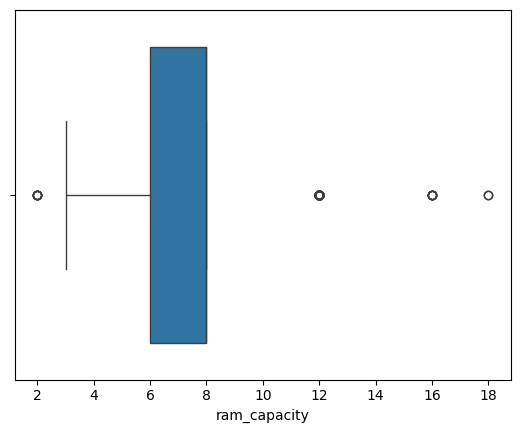

In [21]:
sns.boxplot(x=df['ram_capacity'])

### <a id="num_univariate_4"></a>
#### <b><span style='color:darkorange'>Step 4.2.4 |</span><span style='color:teal'> Outlier Detection for 'price'</span></b>

<Axes: xlabel='price'>

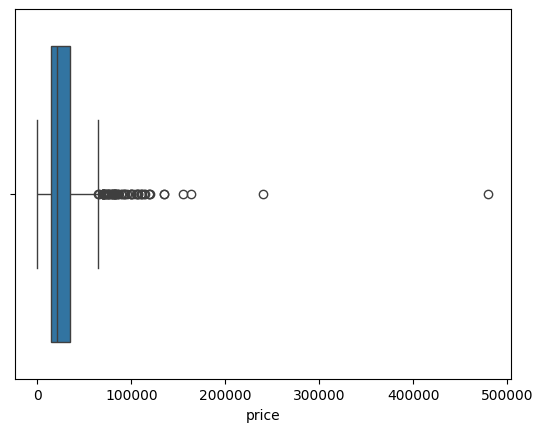

In [22]:
sns.boxplot(x=df['price'])

In [23]:
# Find outliers in 'price' column
    
# Calculate IQR for 'price' column
q125 = df['price'].quantile(0.25)
q375 = df['price'].quantile(0.75)
print(f"Q1 (25th percentile): {q125}")
print(f"Q3 (75th percentile): {q375}")
iqr = q375 - q125
print(f"IQR (Interquartile Range): {iqr}")

# Identify outlier rows in 'price' column
low_price = q125 - 1.5 * iqr
high_price = q375 + 1.5 * iqr
df = df[(df['price'] >= low_price) & (df['price'] <= high_price)]

Q1 (25th percentile): 14990.0
Q3 (75th percentile): 34959.25
IQR (Interquartile Range): 19969.25


In [24]:
# Check for rows where 'price' is 0
print('Rows where price is 0:' ,df[df['price'] == 0])

Rows where price is 0:     brand_name                           model  rating  has_5g  has_nfc  \
986       iqoo  iQOO Z6 Lite (6GB RAM + 128GB)      79    True    False   

     has_ir_blaster processor_brand  num_cores  processor_speed  \
986           False      snapdragon          8              2.0   

     battery_capacity  ...  refresh_rate    resolution  num_rear_cameras  \
986              5000  ...         120.0  1080 x 2408                  2   

     num_front_cameras       os  primary_camera_rear primary_camera_front  \
986                  1  android                   50                    8   

     extended_memory_available  extended_upto price  
986                          1           1024   0.0  

[1 rows x 25 columns]


/home/vscode/.local/lib/python3.11/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


In [25]:
# Remove rows where 'price' is 0 by plot
df = df[df['price'] != 0]

# After removing rows where 'price' is 0
print('Rows where price is 0:' ,df[df['price'] == 0])

Rows where price is 0: Empty DataFrame
Columns: [brand_name, model, rating, has_5g, has_nfc, has_ir_blaster, processor_brand, num_cores, processor_speed, battery_capacity, fast_charging_available, fast_charging, ram_capacity, internal_memory, screen_size, refresh_rate, resolution, num_rear_cameras, num_front_cameras, os, primary_camera_rear, primary_camera_front, extended_memory_available, extended_upto, price]
Index: []

[0 rows x 25 columns]


In [26]:
df

/home/vscode/.local/lib/python3.11/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,brand_name,model,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,battery_capacity,...,refresh_rate,resolution,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto,price
0,oneplus,OnePlus 11 5G,89,True,True,False,snapdragon,8,3.199219,5000,...,120.0,1440 x 3216,3,1,android,50,16,0,736,54999.0
1,oneplus,OnePlus Nord CE 2 Lite 5G,81,True,False,False,snapdragon,8,2.199219,5000,...,120.0,1080 x 2412,3,1,android,64,16,1,1024,19989.0
2,samsung,Samsung Galaxy A14 5G,75,True,False,False,exynos,8,2.400391,5000,...,90.0,1080 x 2408,3,1,android,50,13,1,1024,16499.0
4,realme,Realme 10 Pro Plus,82,True,False,False,dimensity,8,2.599609,5000,...,120.0,1080 x 2412,3,1,android,108,16,0,736,24999.0
5,samsung,Samsung Galaxy F23 5G (6GB RAM + 128GB),80,True,True,False,snapdragon,8,2.199219,5000,...,120.0,1080 x 2408,3,1,android,50,8,1,1024,16999.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
969,xiaomi,Xiaomi Civi 3,86,True,True,True,dimensity,8,3.099609,5000,...,120.0,1080 x 2400,3,2,android,64,32,0,736,32990.0
970,realme,Realme Narzo 50i Prime (4GB RAM + 64GB),67,False,False,False,tiger,8,1.820312,5000,...,60.0,720 x 1600,1,1,android,8,5,1,1024,8720.0
975,motorola,Motorola Moto Edge S30 Pro,83,True,False,False,snapdragon,8,3.000000,5000,...,120.0,1080 x 2460,3,1,android,64,16,0,736,34990.0
976,honor,Honor X8 5G,75,True,False,False,snapdragon,8,2.199219,5000,...,60.0,720 x 1600,3,1,android,48,8,1,1024,14990.0


<a id="read"></a>
# <p style="background-color:maroon; font-family:calibri; font-size:80%; color:white; text-align:center; border-radius:15px 50px; padding:10px">Step 5 | Feature Engineering</p>

____
<a id="num_univariate"></a>
# <b><span style='color:orangered'>Step 5.1 |</span><span style='color:maroon'> Extract only model names from the 'model' column</span></b>  

In [27]:
df['model']

0                                OnePlus 11 5G
1                    OnePlus Nord CE 2 Lite 5G
2                        Samsung Galaxy A14 5G
4                           Realme 10 Pro Plus
5      Samsung Galaxy F23 5G (6GB RAM + 128GB)
                        ...                   
969                              Xiaomi Civi 3
970    Realme Narzo 50i Prime (4GB RAM + 64GB)
975                 Motorola Moto Edge S30 Pro
976                                Honor X8 5G
977            POCO X4 GT 5G (8GB RAM + 256GB)
Name: model, Length: 675, dtype: str

### <a id="num_univariate_4"></a>
#### <b><span style='color:darkorange'>Step 5.1.1 |</span><span style='color:teal'> Remove RAM and internal memory from 'model' column</span></b>

In [28]:
df[df['model'].str.contains('RAM')].sample(3)

/home/vscode/.local/lib/python3.11/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,brand_name,model,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,battery_capacity,...,refresh_rate,resolution,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto,price
748,samsung,Samsung Galaxy A03 (4GB RAM + 64GB),69,False,False,False,unisoc,8,1.599609,5000,...,60.0,720 x 1560,2,1,android,48,5,1,1024,11499.0
364,oneplus,OnePlus 10T (12GB RAM + 256GB),87,True,True,False,snapdragon,8,3.199219,4800,...,120.0,1080 x 2412,3,1,android,50,16,0,736,50999.0
605,xiaomi,Xiaomi Redmi Note 11S (6GB RAM + 128GB),81,False,False,True,helio,8,2.050781,5000,...,90.0,1080 x 2400,4,1,android,108,16,1,512,15499.0


In [29]:
df[df['model'].str.contains('RAM')]['model'].apply(lambda x : x.split('(')[0])

5          Samsung Galaxy F23 5G 
13                    Vivo T1 5G 
26     OnePlus Nord CE 2 Lite 5G 
30                 Realme 10 Pro 
43            Realme 10 Pro Plus 
                  ...            
939           Samsung Galaxy F41 
943                OPPO A53 2020 
947              Xiaomi Mi 10 5G 
970       Realme Narzo 50i Prime 
977                POCO X4 GT 5G 
Name: model, Length: 169, dtype: str

In [30]:
df[df['model'].str.contains('RAM')]['model'].head(3)

5         Samsung Galaxy F23 5G (6GB RAM + 128GB)
13                   Vivo T1 5G (6GB RAM + 128GB)
26    OnePlus Nord CE 2 Lite 5G (8GB RAM + 128GB)
Name: model, dtype: str

In [31]:
df.loc[df['model'].str.contains('RAM'), 'model'] = df.loc[df['model'].str.contains('RAM'), 'model'].apply(lambda x : x.split('(')[0].strip())
df.head(3)

/home/vscode/.local/lib/python3.11/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,brand_name,model,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,battery_capacity,...,refresh_rate,resolution,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto,price
0,oneplus,OnePlus 11 5G,89,True,True,False,snapdragon,8,3.199219,5000,...,120.0,1440 x 3216,3,1,android,50,16,0,736,54999.0
1,oneplus,OnePlus Nord CE 2 Lite 5G,81,True,False,False,snapdragon,8,2.199219,5000,...,120.0,1080 x 2412,3,1,android,64,16,1,1024,19989.0
2,samsung,Samsung Galaxy A14 5G,75,True,False,False,exynos,8,2.400391,5000,...,90.0,1080 x 2408,3,1,android,50,13,1,1024,16499.0


### <a id="num_univariate_4"></a>
#### <b><span style='color:darkorange'>Step 5.1.2 |</span><span style='color:teal'> Remove 5G from 'model' column</span></b>

In [32]:
df.loc[df['model'].str.contains('5G'), 'model'] = df.loc[df['model'].str.contains('5G'), 'model'].apply(lambda x : x.split('5G')[0].strip())
df.head(3)

/home/vscode/.local/lib/python3.11/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,brand_name,model,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,battery_capacity,...,refresh_rate,resolution,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto,price
0,oneplus,OnePlus 11,89,True,True,False,snapdragon,8,3.199219,5000,...,120.0,1440 x 3216,3,1,android,50,16,0,736,54999.0
1,oneplus,OnePlus Nord CE 2 Lite,81,True,False,False,snapdragon,8,2.199219,5000,...,120.0,1080 x 2412,3,1,android,64,16,1,1024,19989.0
2,samsung,Samsung Galaxy A14,75,True,False,False,exynos,8,2.400391,5000,...,90.0,1080 x 2408,3,1,android,50,13,1,1024,16499.0


### <a id="num_univariate_4"></a>
#### <b><span style='color:darkorange'>Step 5.1.3 |</span><span style='color:teal'> Remove Brand from 'model' column</span></b>

In [33]:
df['model']= df['model'].apply(lambda x : ' '.join(x.split()[1:]))

In [34]:
df.head(3)

/home/vscode/.local/lib/python3.11/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,brand_name,model,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,battery_capacity,...,refresh_rate,resolution,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto,price
0,oneplus,11,89,True,True,False,snapdragon,8,3.199219,5000,...,120.0,1440 x 3216,3,1,android,50,16,0,736,54999.0
1,oneplus,Nord CE 2 Lite,81,True,False,False,snapdragon,8,2.199219,5000,...,120.0,1080 x 2412,3,1,android,64,16,1,1024,19989.0
2,samsung,Galaxy A14,75,True,False,False,exynos,8,2.400391,5000,...,90.0,1080 x 2408,3,1,android,50,13,1,1024,16499.0


____
<a id="num_univariate"></a>
# <b><span style='color:orangered'>Step 5.2 |</span><span style='color:maroon'> Split 'resolution' column to 'width' and 'height'</span></b>  

In [35]:
# Split 'resolution' into 'resolution_width' and 'resolution_height'
df['resolution_width'] = df['resolution'].apply(lambda x : x.split('x')[0].strip())
df['resolution_height'] = df['resolution'].apply(lambda x : x.split('x')[1].strip())

# Convert 'resolution_width' and 'resolution_height' to float16
df['resolution_height'] = df['resolution_height'].astype('float16')
df['resolution_width'] = df['resolution_width'].astype('float16')

# Move 'price' column to the end
price_col = df.pop('price')
df['price'] = price_col

# Remove the original 'resolution' column
df.drop(columns=['resolution'], inplace=True)

In [36]:
df.columns

Index(['brand_name', 'model', 'rating', 'has_5g', 'has_nfc', 'has_ir_blaster',
       'processor_brand', 'num_cores', 'processor_speed', 'battery_capacity',
       'fast_charging_available', 'fast_charging', 'ram_capacity',
       'internal_memory', 'screen_size', 'refresh_rate', 'num_rear_cameras',
       'num_front_cameras', 'os', 'primary_camera_rear',
       'primary_camera_front', 'extended_memory_available', 'extended_upto',
       'resolution_width', 'resolution_height', 'price'],
      dtype='str')

____
<a id="num_univariate"></a>
# <b><span style='color:orangered'>Step 5.3 |</span><span style='color:maroon'> Feature Selection (Remove Redundant Features)</span></b>  

In [37]:
df[['fast_charging_available' ,'fast_charging']]

/home/vscode/.local/lib/python3.11/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,fast_charging_available,fast_charging
0,100.0,100.0
1,33.0,33.0
2,15.0,15.0
4,67.0,67.0
5,25.0,25.0
...,...,...
969,80.0,80.0
970,10.0,10.0
975,68.0,68.0
976,22.0,22.0


In [38]:
# Remove 'fast_charging_available' column
df.drop(columns=['fast_charging_available'], inplace=True)
df.columns

Index(['brand_name', 'model', 'rating', 'has_5g', 'has_nfc', 'has_ir_blaster',
       'processor_brand', 'num_cores', 'processor_speed', 'battery_capacity',
       'fast_charging', 'ram_capacity', 'internal_memory', 'screen_size',
       'refresh_rate', 'num_rear_cameras', 'num_front_cameras', 'os',
       'primary_camera_rear', 'primary_camera_front',
       'extended_memory_available', 'extended_upto', 'resolution_width',
       'resolution_height', 'price'],
      dtype='str')

____
<a id="num_univariate"></a>
# <b><span style='color:orangered'>Step 5.4 |</span><span style='color:maroon'> Convert df to CSV file</span></b>  

In [39]:
df.to_csv("smartphone_cleaned_v1.csv", index=False)

<a id="read"></a>
# <p style="background-color:maroon; font-family:calibri; font-size:80%; color:white; text-align:center; border-radius:15px 50px; padding:10px">Step 6 | Exploratory Data Analysis (EDA)</p>

In [40]:
# Load the final cleaned data created at the last of step 5 
df = pd.read_csv("smartphone_cleaned_v1.csv")
df.head(3)

,brand_name,model,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,battery_capacity,...,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto,resolution_width,resolution_height,price
0,oneplus,11,89,True,True,False,snapdragon,8,3.2,5000,...,3,1,android,50,16,0,736,1440.0,3216.0,54999.0
1,oneplus,Nord CE 2 Lite,81,True,False,False,snapdragon,8,2.2,5000,...,3,1,android,64,16,1,1024,1080.0,2412.0,19989.0
2,samsung,Galaxy A14,75,True,False,False,exynos,8,2.4,5000,...,3,1,android,50,13,1,1024,1080.0,2408.0,16499.0


In [41]:

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 675 entries, 0 to 674
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   brand_name                 675 non-null    str    
 1   model                      675 non-null    str    
 2   rating                     675 non-null    int64  
 3   has_5g                     675 non-null    bool   
 4   has_nfc                    675 non-null    bool   
 5   has_ir_blaster             675 non-null    bool   
 6   processor_brand            675 non-null    str    
 7   num_cores                  675 non-null    int64  
 8   processor_speed            675 non-null    float64
 9   battery_capacity           675 non-null    int64  
 10  fast_charging              675 non-null    float64
 11  ram_capacity               675 non-null    int64  
 12  internal_memory            675 non-null    int64  
 13  screen_size                675 non-null    float64
 14  refre

In [42]:
df.describe()

,rating,num_cores,processor_speed,battery_capacity,fast_charging,ram_capacity,internal_memory,screen_size,refresh_rate,num_rear_cameras,num_front_cameras,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto,resolution_width,resolution_height,price
count,675.000000,675.000000,675.000000,675.000000,675.000000,675.000000,675.000000,675.000000,675.000000,675.000000,675.000000,675.000000,675.000000,675.000000,675.000000,675.000000,675.000000,675.000000
mean,79.900741,7.949630,2.423289,4946.745185,44.968889,6.767407,133.309630,6.573170,97.168889,2.962963,1.028148,58.242963,18.103704,0.656296,767.668148,1077.626667,2276.242963,23890.496296
std,5.671569,0.439664,0.405506,1027.106195,34.393006,2.323433,61.622502,0.159804,26.649187,0.653766,0.165519,31.025503,11.019725,0.475296,256.660653,252.114176,410.814260,12946.434935
min,67.000000,4.000000,1.600000,1821.000000,10.000000,2.000000,32.000000,4.700000,60.000000,1.000000,1.000000,8.000000,5.000000,0.000000,128.000000,720.000000,720.000000,5785.000000
25%,76.000000,8.000000,2.200000,4600.000000,18.000000,6.000000,128.000000,6.500000,60.000000,3.000000,1.000000,50.000000,8.000000,0.000000,736.000000,1080.000000,2400.000000,14499.000000
50%,81.000000,8.000000,2.360000,5000.000000,33.000000,6.000000,128.000000,6.580000,90.000000,3.000000,1.000000,50.000000,16.000000,1.000000,736.000000,1080.000000,2400.000000,19990.000000
75%,84.000000,8.000000,2.730000,5000.000000,66.000000,8.000000,128.000000,6.670000,120.000000,3.000000,1.000000,64.000000,20.000000,1.000000,1024.000000,1080.000000,2408.000000,29990.000000
max,89.000000,8.000000,3.200000,22000.000000,240.000000,16.000000,512.000000,6.950000,165.000000,4.000000,2.000000,200.000000,60.000000,1.000000,2048.000000,2460.000000,3216.000000,64800.000000


In [43]:
# Check for missing values
print(df.isnull().sum())

brand_name                   0
model                        0
rating                       0
has_5g                       0
has_nfc                      0
has_ir_blaster               0
processor_brand              0
num_cores                    0
processor_speed              0
battery_capacity             0
fast_charging                0
ram_capacity                 0
internal_memory              0
screen_size                  0
refresh_rate                 0
num_rear_cameras             0
num_front_cameras            0
os                           0
primary_camera_rear          0
primary_camera_front         0
extended_memory_available    0
extended_upto                0
resolution_width             0
resolution_height            0
price                        0
dtype: int64


<Axes: >

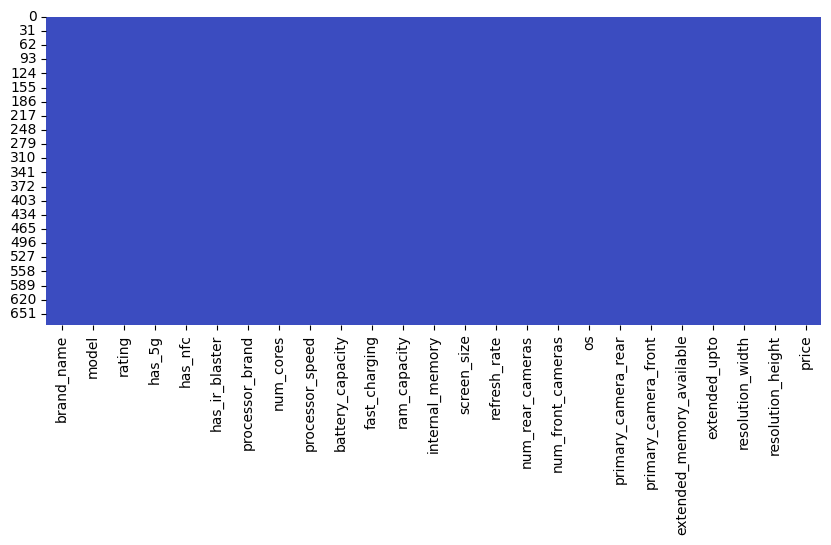

In [44]:
# Visualize missing values
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='coolwarm') # Output: no missing values

____
<a id="num_univariate"></a>
# <b><span style='color:orangered'>Step 6.1 |</span><span style='color:maroon'> Univariate Analysis</span></b>  

### <a id="num_univariate_4"></a>
#### <b><span style='color:darkorange'>Step 6.1.1 |</span><span style='color:teal'> Univariate Analysis for Categorical Features</span></b>

In [45]:
# Filter out categorical features
df_categorical = df[['brand_name','model','num_cores', 'extended_memory_available', 'has_5g', 'has_nfc', 'has_ir_blaster', 'os']].astype(str)

# Calculate 'Number of unique values' and 'Unique values' for each feature
unique_counts = df_categorical.nunique()
unique_values = df_categorical.apply(lambda col: col.unique().tolist())

# Create new dataframe with the results
pd.DataFrame({'Number of Unique Values': unique_counts, 'Unique Values': unique_values})

,Number of Unique Values,Unique Values
brand_name,34,"[oneplus, samsung, realme, xiaomi, nothing, op..."
model,494,"[11, Nord CE 2 Lite, Galaxy A14, 10 Pro Plus, ..."
num_cores,3,"[8, 4, 6]"
extended_memory_available,2,"[0, 1]"
has_5g,2,"[True, False]"
has_nfc,2,"[True, False]"
has_ir_blaster,2,"[False, True]"
os,3,"[android, ios, other]"


In [46]:
!pip install --upgrade ipython notebook

Defaulting to user installation because normal site-packages is not writeable


In [47]:
# Create the subplots
fig = make_subplots(rows=3, cols=3, specs=[[{'type':'domain'}]*3]*3, vertical_spacing=0.05, horizontal_spacing=0.01)

# Loop through all the features and add the pie chart to the subplot
for i, feature in enumerate(df_categorical.columns):
    value_counts = df_categorical[feature].value_counts()
    labels = value_counts.index.tolist()
    values = value_counts.values.tolist()

    # Define color map based on orangered color
    cmap = colors.LinearSegmentedColormap.from_list("orangered", ["orangered", "white"])
    norm = colors.Normalize(vmin=0, vmax=len(labels))
    color_list = [colors.rgb2hex(cmap(norm(i))) for i in range(len(labels))]

    # Create the pie chart
    pie_chart = go.Pie(
        labels=labels,
        values=values,
        hole=0.6,
        marker=dict(colors=color_list, line=dict(color='white', width=3)),
        textposition='inside',
        textinfo='percent+label',
        title=feature,  # Add title with the feature name
        title_font=dict(size=25, color='black', family='Calibri')
    )

    # Add the pie chart to the subplot
    if i < 8:
        row = i // 3 + 1
        col = i % 3 + 1
        fig.add_trace(pie_chart, row=row, col=col)

# Update the layout
fig.update_layout(showlegend=False, height=1000, width=980, 
                   title={
                          'text':"Distribution of Categorical Variables",
                          'y':0.95,
                          'x':0.5,
                          'xanchor':'center',
                          'yanchor':'top',
                          'font': {'size':28, 'color':'black', 'family':'Calibri'}
                         })
# Save as high quality image acceptable in IEEE journal and conference papers
fig.update_layout()
fig.write_image('Figure 6 Univariate Distribution of Categorical Features.png', 
                scale=3,  # 3x scale = ~600 DPI equivalent
                width=980, 
                height=1000)

# Show the figure
fig.show()

### <a id="num_univariate_4"></a>
#### <b><span style='color:darkorange'>Step 6.1.2 |</span><span style='color:teal'> Univariate Analysis for Numerical Features</span></b>

In [48]:
# Filter out numerical features
df_numerical = df.drop(df_categorical.columns, axis=1)

# Generate descriptive statistics and Transpose
df_numerical.describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
rating,675.0,79.9,5.7,67.0,76.0,81.0,84.0,89.0
processor_speed,675.0,2.4,0.4,1.6,2.2,2.4,2.7,3.2
battery_capacity,675.0,4946.7,1027.1,1821.0,4600.0,5000.0,5000.0,22000.0
fast_charging,675.0,45.0,34.4,10.0,18.0,33.0,66.0,240.0
ram_capacity,675.0,6.8,2.3,2.0,6.0,6.0,8.0,16.0
internal_memory,675.0,133.3,61.6,32.0,128.0,128.0,128.0,512.0
screen_size,675.0,6.6,0.2,4.7,6.5,6.6,6.7,7.0
refresh_rate,675.0,97.2,26.6,60.0,60.0,90.0,120.0,165.0
num_rear_cameras,675.0,3.0,0.7,1.0,3.0,3.0,3.0,4.0
num_front_cameras,675.0,1.0,0.2,1.0,1.0,1.0,1.0,2.0


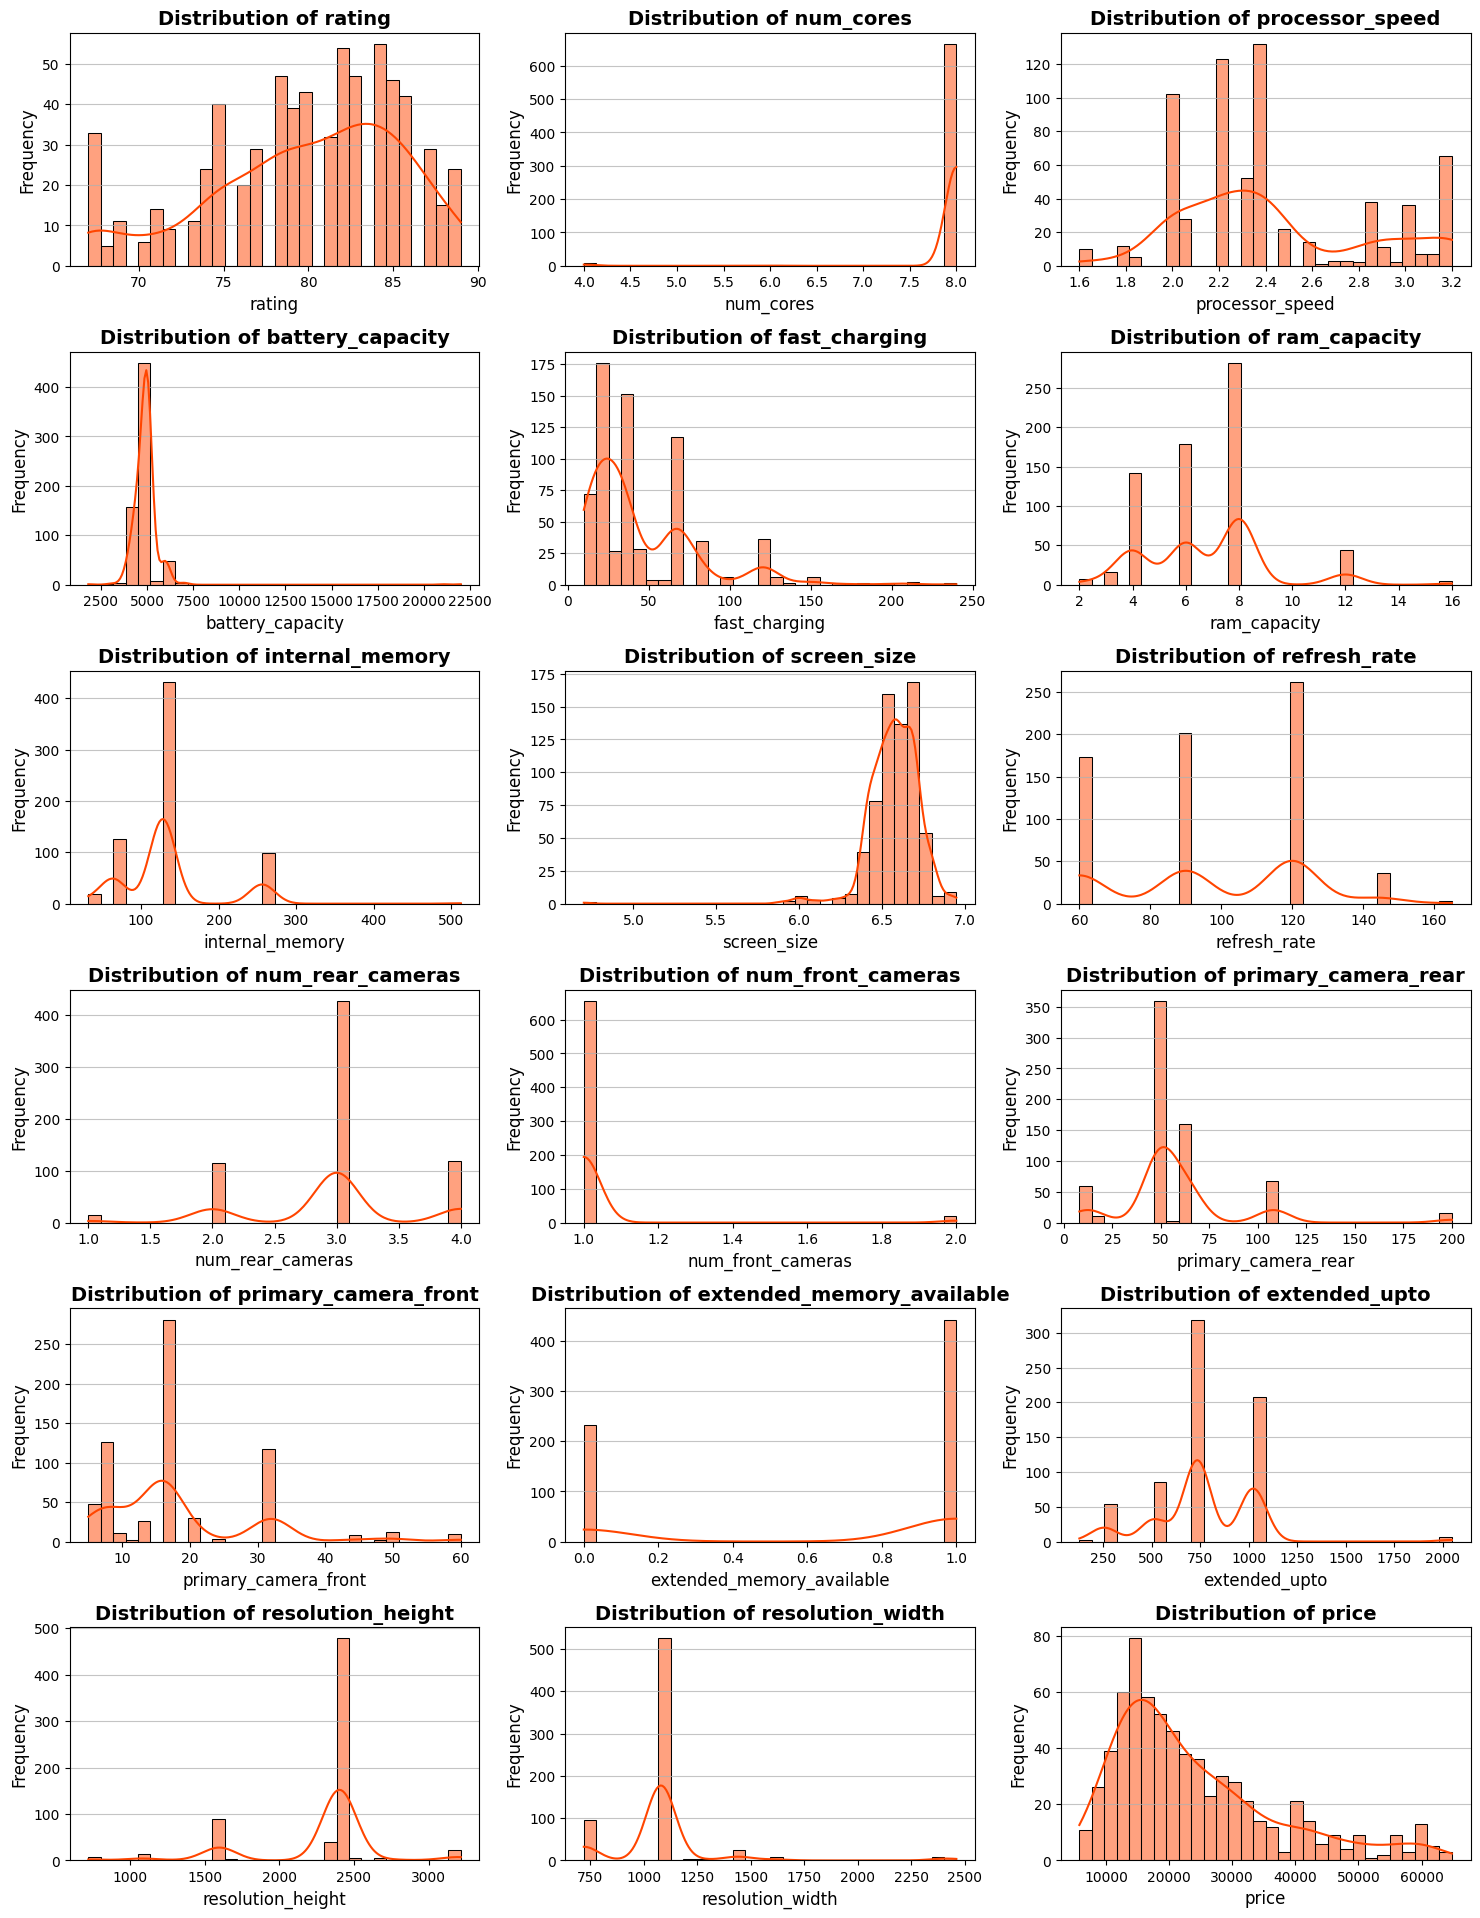

In [ ]:
# All numeric columns (example list)
cols = ['rating', 'num_cores', 'processor_speed', 'battery_capacity', 'fast_charging', 'ram_capacity',
        'internal_memory', 'screen_size', 'refresh_rate', 'num_rear_cameras',
        'num_front_cameras', 'primary_camera_rear', 'primary_camera_front',
        'extended_memory_available', 'extended_upto', 'resolution_height',
        'resolution_width', 'price']

# Create subplots
fig, ax = plt.subplots(nrows=7, ncols=3, figsize=(15, 22))
ax = ax.flatten()

# Loop through columns and axes together
for i, col in enumerate(cols):
    sns.histplot(df[col], kde=True, color='orangered', bins=30, ax=ax[i])
    ax[i].set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    ax[i].set_xlabel(col, fontsize=12)
    ax[i].set_ylabel('Frequency', fontsize=12)
    ax[i].grid(axis='y', alpha=0.75)

# Remove empty subplots (if any)
for j in range(i+1, len(ax)):
    fig.delaxes(ax[j])

# Save as high quality image acceptable in IEEE journal and conference papers
plt.tight_layout()
plt.savefig('Figure 5 Univariate Analysis for Numerical Features.png', dpi=600, bbox_inches='tight', 
            format='png', facecolor='white', edgecolor='none')
plt.show()


In [50]:
df.columns

Index(['brand_name', 'model', 'rating', 'has_5g', 'has_nfc', 'has_ir_blaster',
       'processor_brand', 'num_cores', 'processor_speed', 'battery_capacity',
       'fast_charging', 'ram_capacity', 'internal_memory', 'screen_size',
       'refresh_rate', 'num_rear_cameras', 'num_front_cameras', 'os',
       'primary_camera_rear', 'primary_camera_front',
       'extended_memory_available', 'extended_upto', 'resolution_width',
       'resolution_height', 'price'],
      dtype='str')

____
# <b><span style='color:orangered'>Step 6.2 |</span><span style='color:maroon'> Bivariate Analysis</span></b>


### <a id="num_univariate_4"></a>
#### <b><span style='color:darkorange'>Step 6.2.1 |</span><span style='color:teal'> Bivariate Analysis for Categorical Features</span></b>

/tmp/ipykernel_103104/407142811.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='price', ax=axes[i], palette=color_list)
/tmp/ipykernel_103104/407142811.py:20: UserWarning: 
The palette list has fewer values (3) than needed (34) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=df, x=col, y='price', ax=axes[i], palette=color_list)
/tmp/ipykernel_103104/407142811.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='price', ax=axes[i], palette=color_list)
/tmp/ipykernel_103104/407142811.py:20: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.barplot(data=df, x=col, y='pric

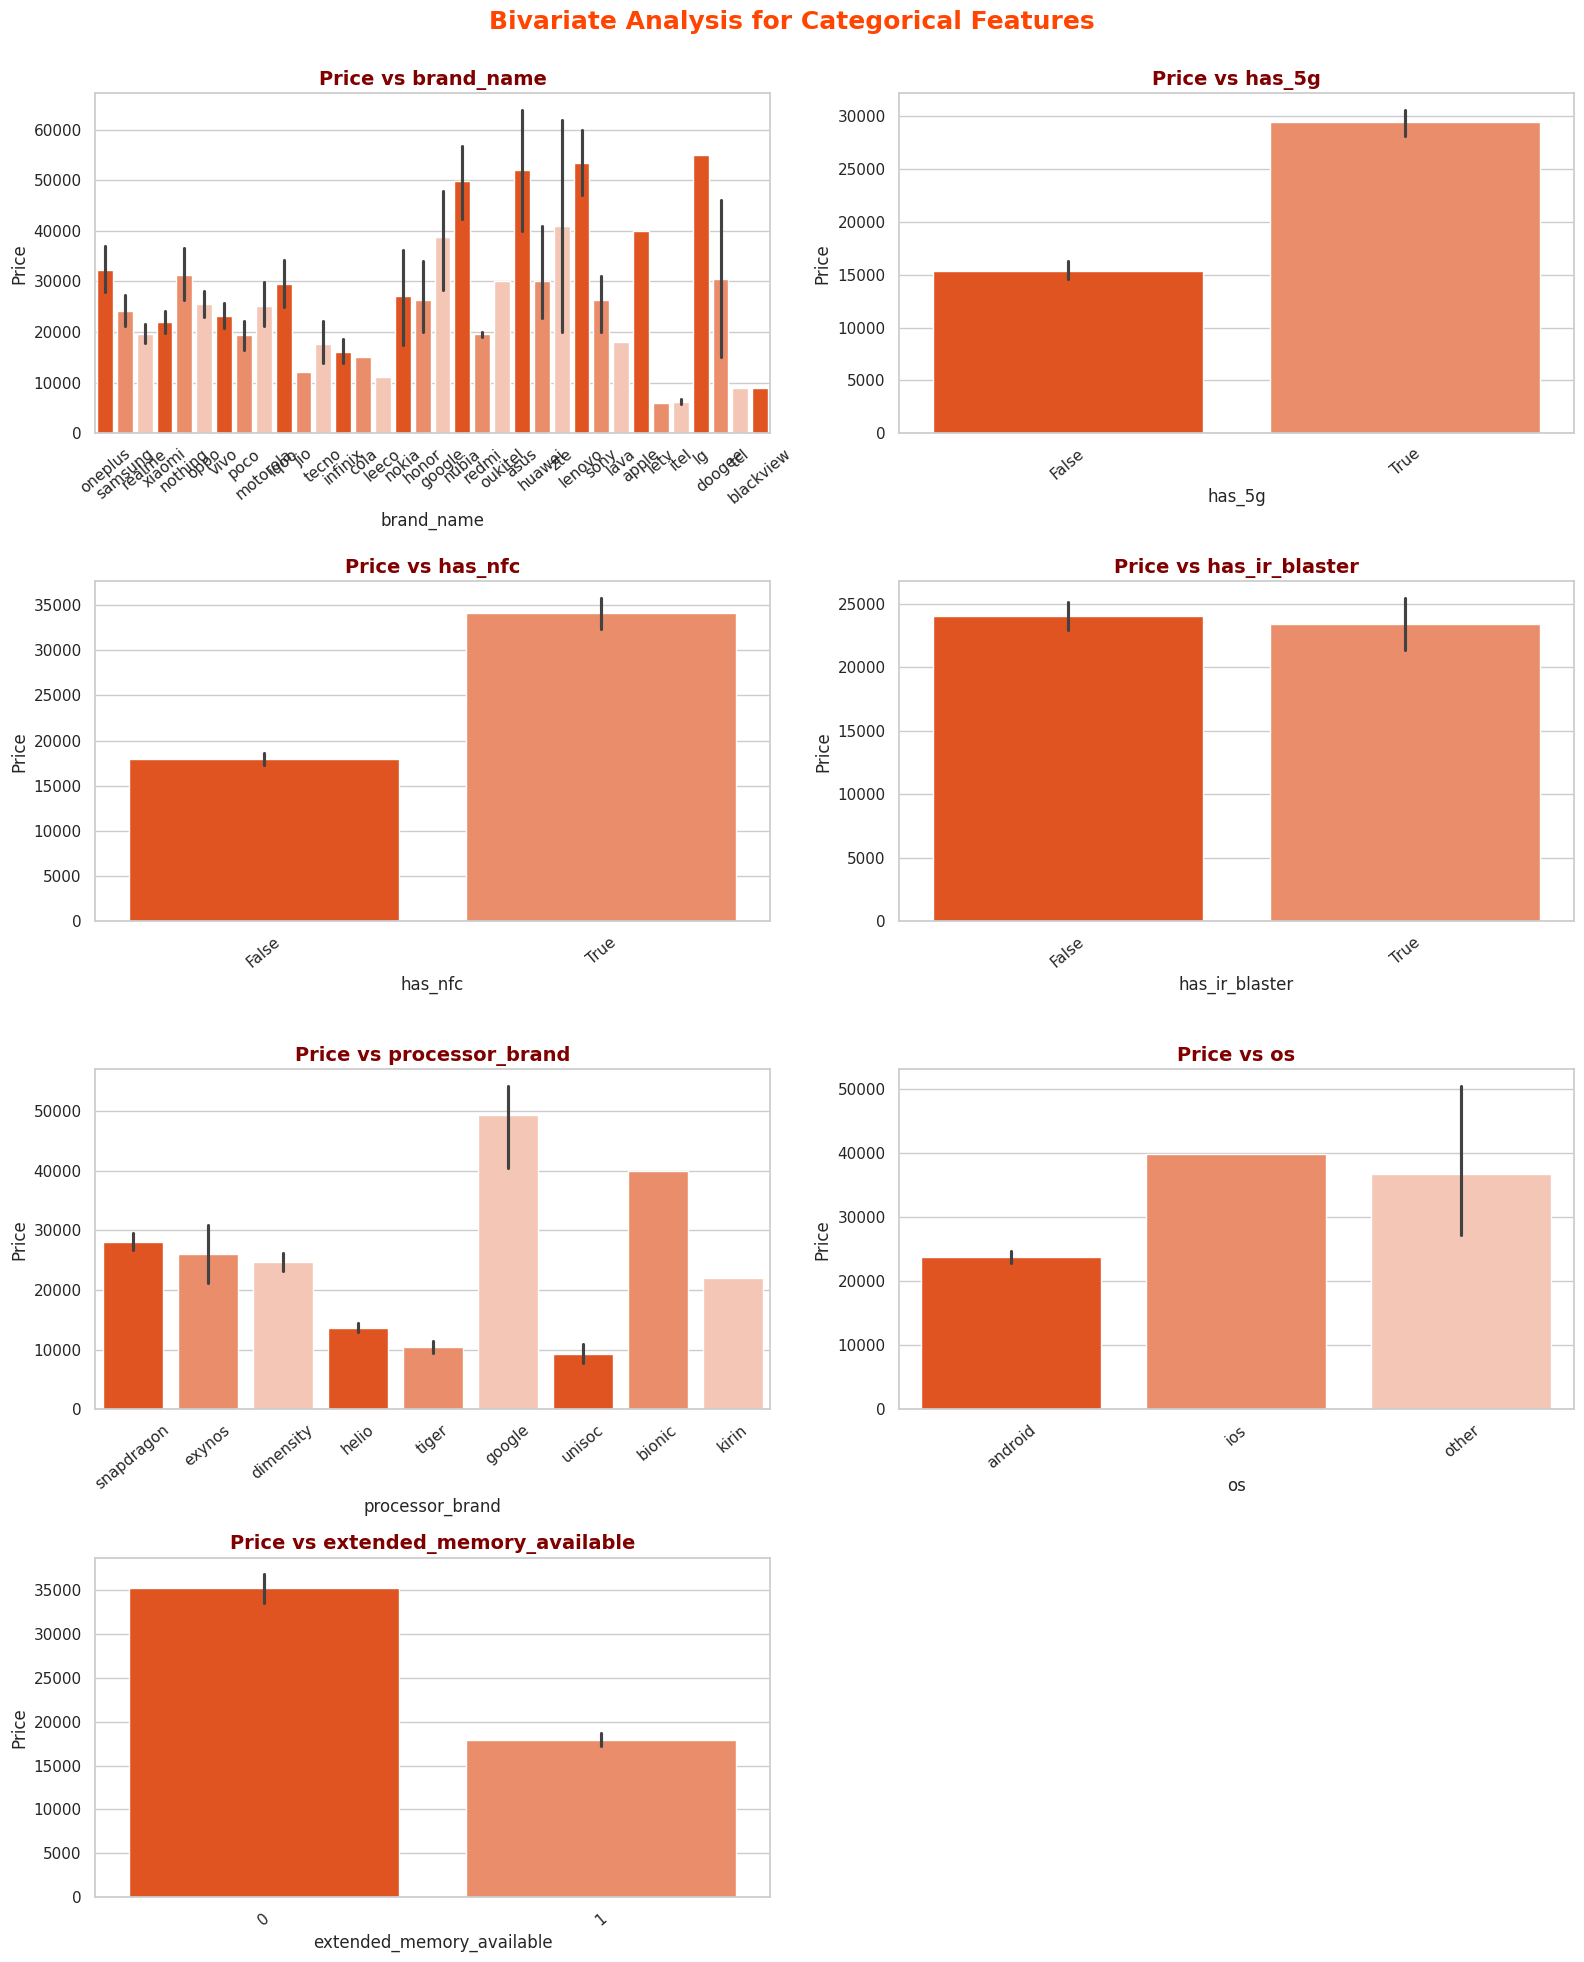

In [ ]:
# Set theme for professional look
sns.set_theme(style="whitegrid", palette="coolwarm")

# Select categorical columns (excluding target column)
cat_cols = ['brand_name', 'has_5g', 'has_nfc', 'has_ir_blaster',
            'processor_brand', 'os',
            'extended_memory_available']

# Number of rows and columns for subplots (2 per row)
rows = math.ceil(len(cat_cols) / 2)
fig, axes = plt.subplots(rows, 2, figsize=(16, rows * 5))
axes = axes.flatten()

cmap = colors.LinearSegmentedColormap.from_list("orangered", ["orangered", "white"])
norm = colors.Normalize(vmin=0, vmax=len(labels))
color_list = [colors.rgb2hex(cmap(norm(i))) for i in range(len(labels))]

# Loop through categorical columns
for i, col in enumerate(cat_cols):
    sns.barplot(data=df, x=col, y='price', ax=axes[i], palette=color_list)
    axes[i].set_title(f'Price vs {col}', fontsize=14, color='maroon', fontweight='bold')
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Price', fontsize=12)
    axes[i].tick_params(axis='x', rotation=40)

# Remove empty subplots (if odd number of columns)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Bivariate Analysis for Categorical Features', fontsize=18, color='orangered', fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.98])

# Save as high quality image acceptable in IEEE journal and conference papers
plt.savefig('Figure 8 Bivariate Analysis for Categorical Features.png', dpi=600, bbox_inches='tight', 
            format='png', facecolor='white', edgecolor='none')
plt.show()

### <a id="num_univariate_4"></a>
#### <b><span style='color:darkorange'>Step 6.2.2 |</span><span style='color:teal'> Bivariate Analysis for Numerical Features</span></b>

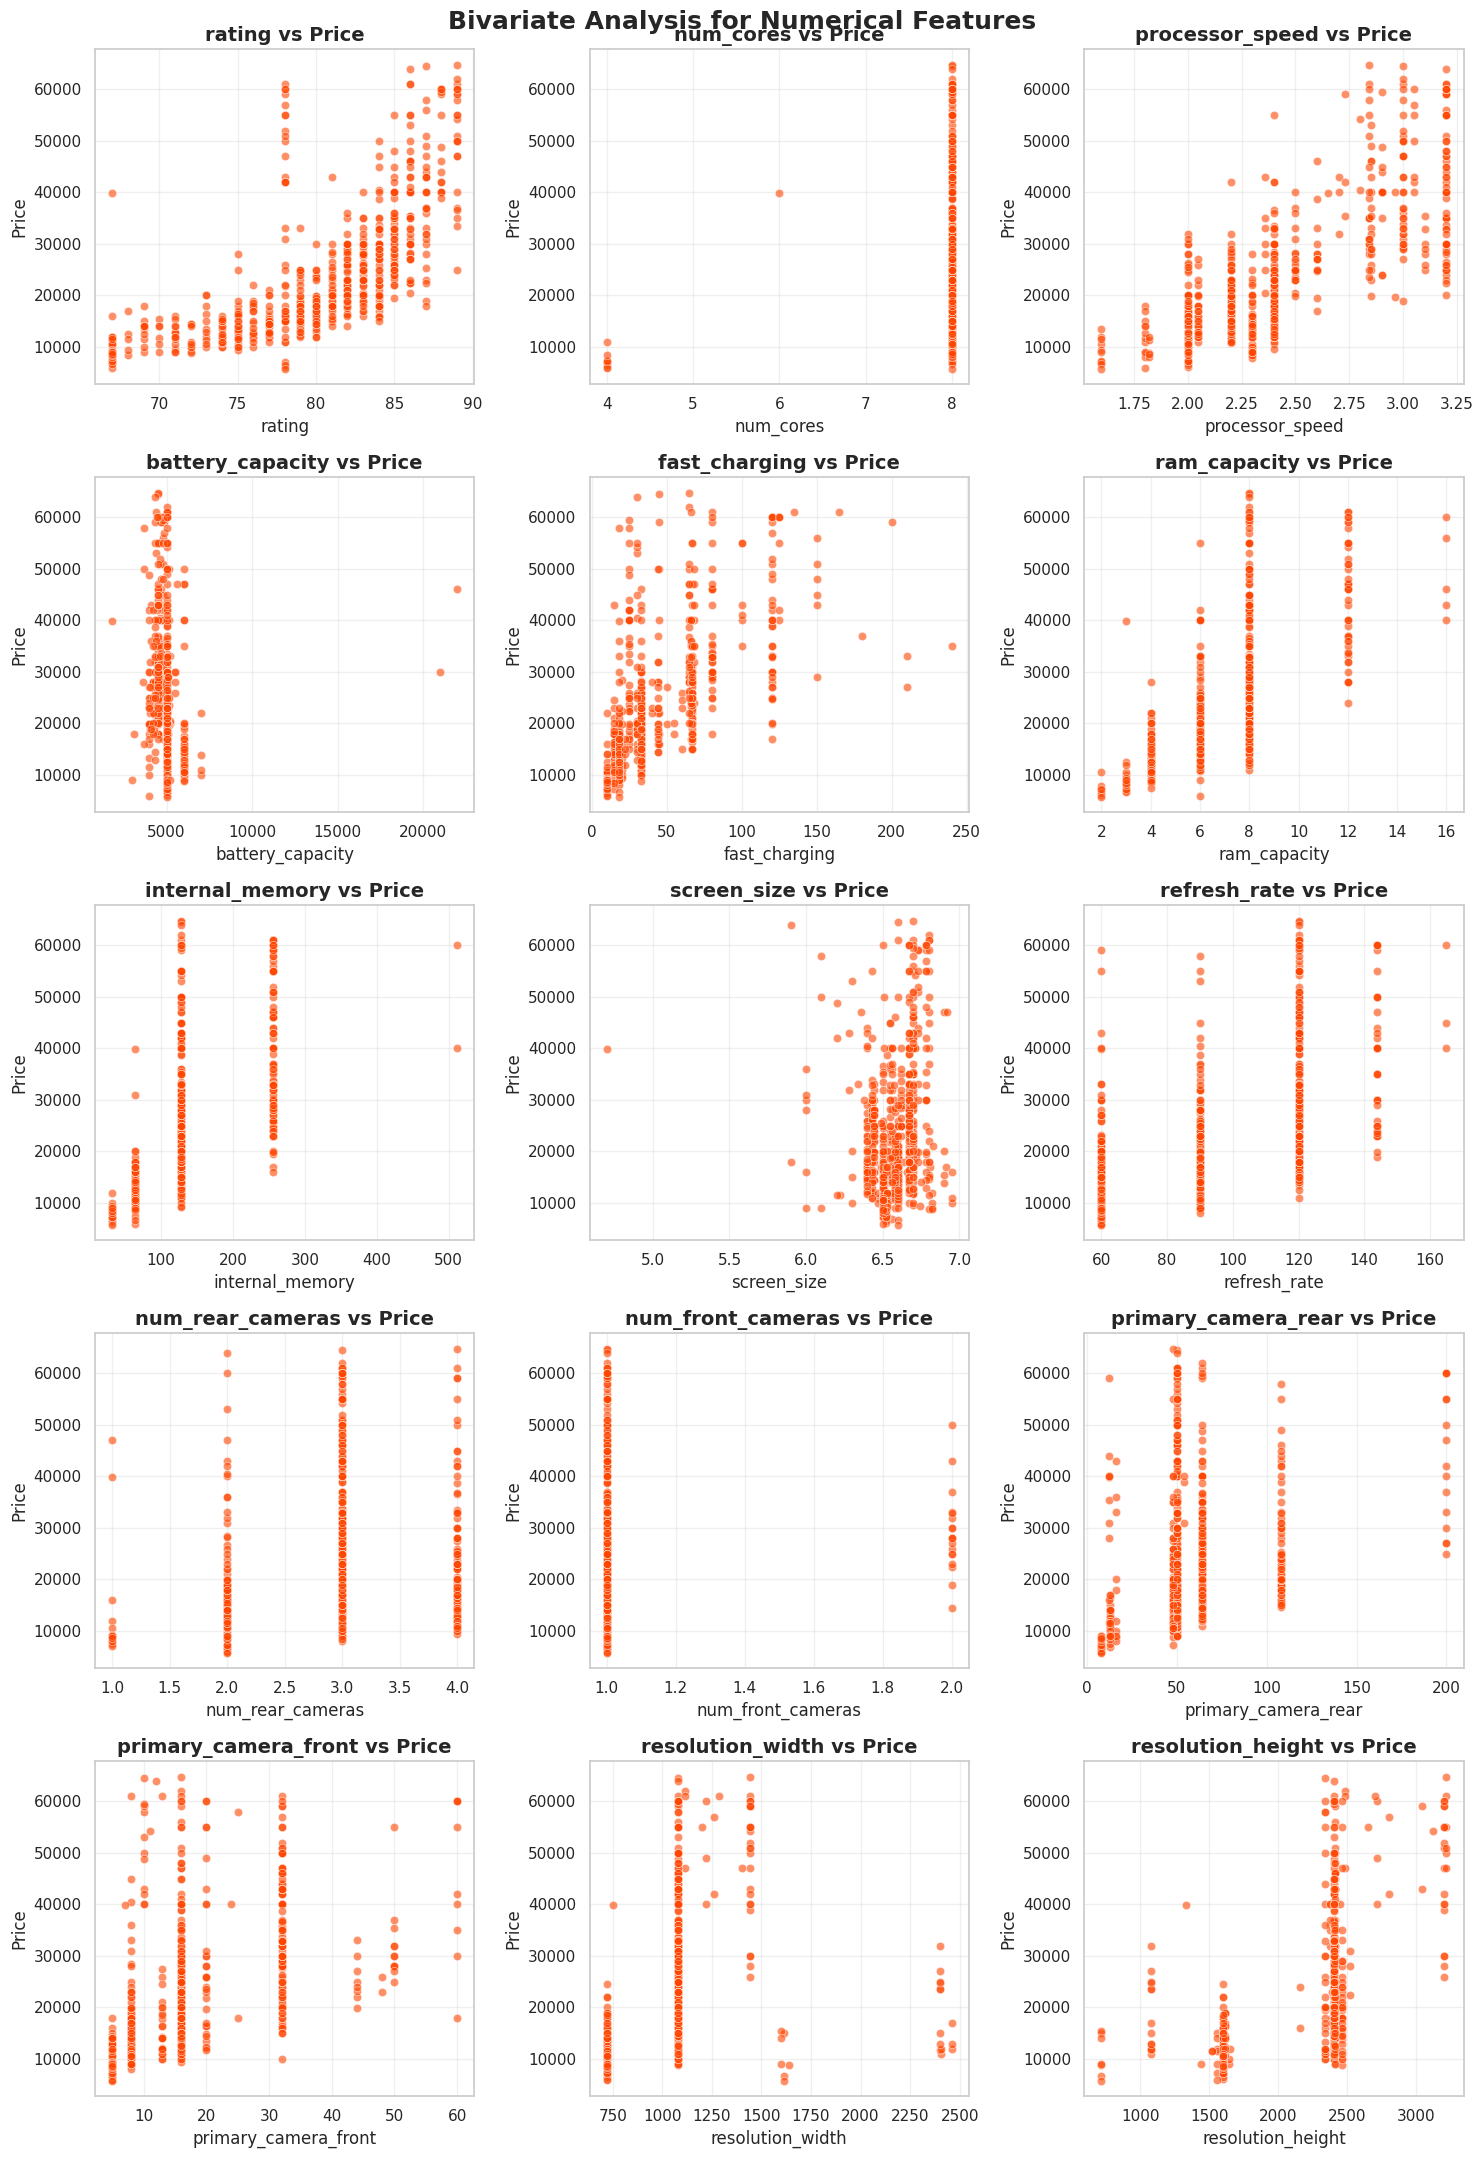

In [52]:
# Select numerical columns
num_cols = ['rating', 'num_cores', 'processor_speed', 'battery_capacity',
            'fast_charging', 'ram_capacity', 'internal_memory', 'screen_size',
            'refresh_rate', 'num_rear_cameras', 'num_front_cameras',
            'primary_camera_rear', 'primary_camera_front', 'resolution_width',
            'resolution_height']

rows = math.ceil(len(num_cols) / 2)
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 22))
axes = axes.flatten()

# Loop through numerical columns
for i, col in enumerate(num_cols):
    sns.scatterplot(data=df, x=col, y='price', ax=axes[i], alpha=0.6, c='orangered')
    axes[i].set_title(f'{col} vs Price', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Price', fontsize=12)
    axes[i].grid(alpha=0.3)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Bivariate Analysis for Numerical Features', fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.98])

# Save as high quality image acceptable in IEEE journal and conference papers
plt.tight_layout()
plt.savefig('Figure 7 Bivariate Analysis for Numerical Features.png', dpi=600, bbox_inches='tight', 
            format='png', facecolor='white', edgecolor='none')
plt.show()


____
# <b><span style='color:orangered'>Step 6.3 |</span><span style='color:maroon'> Multivariate Analysis</span></b>


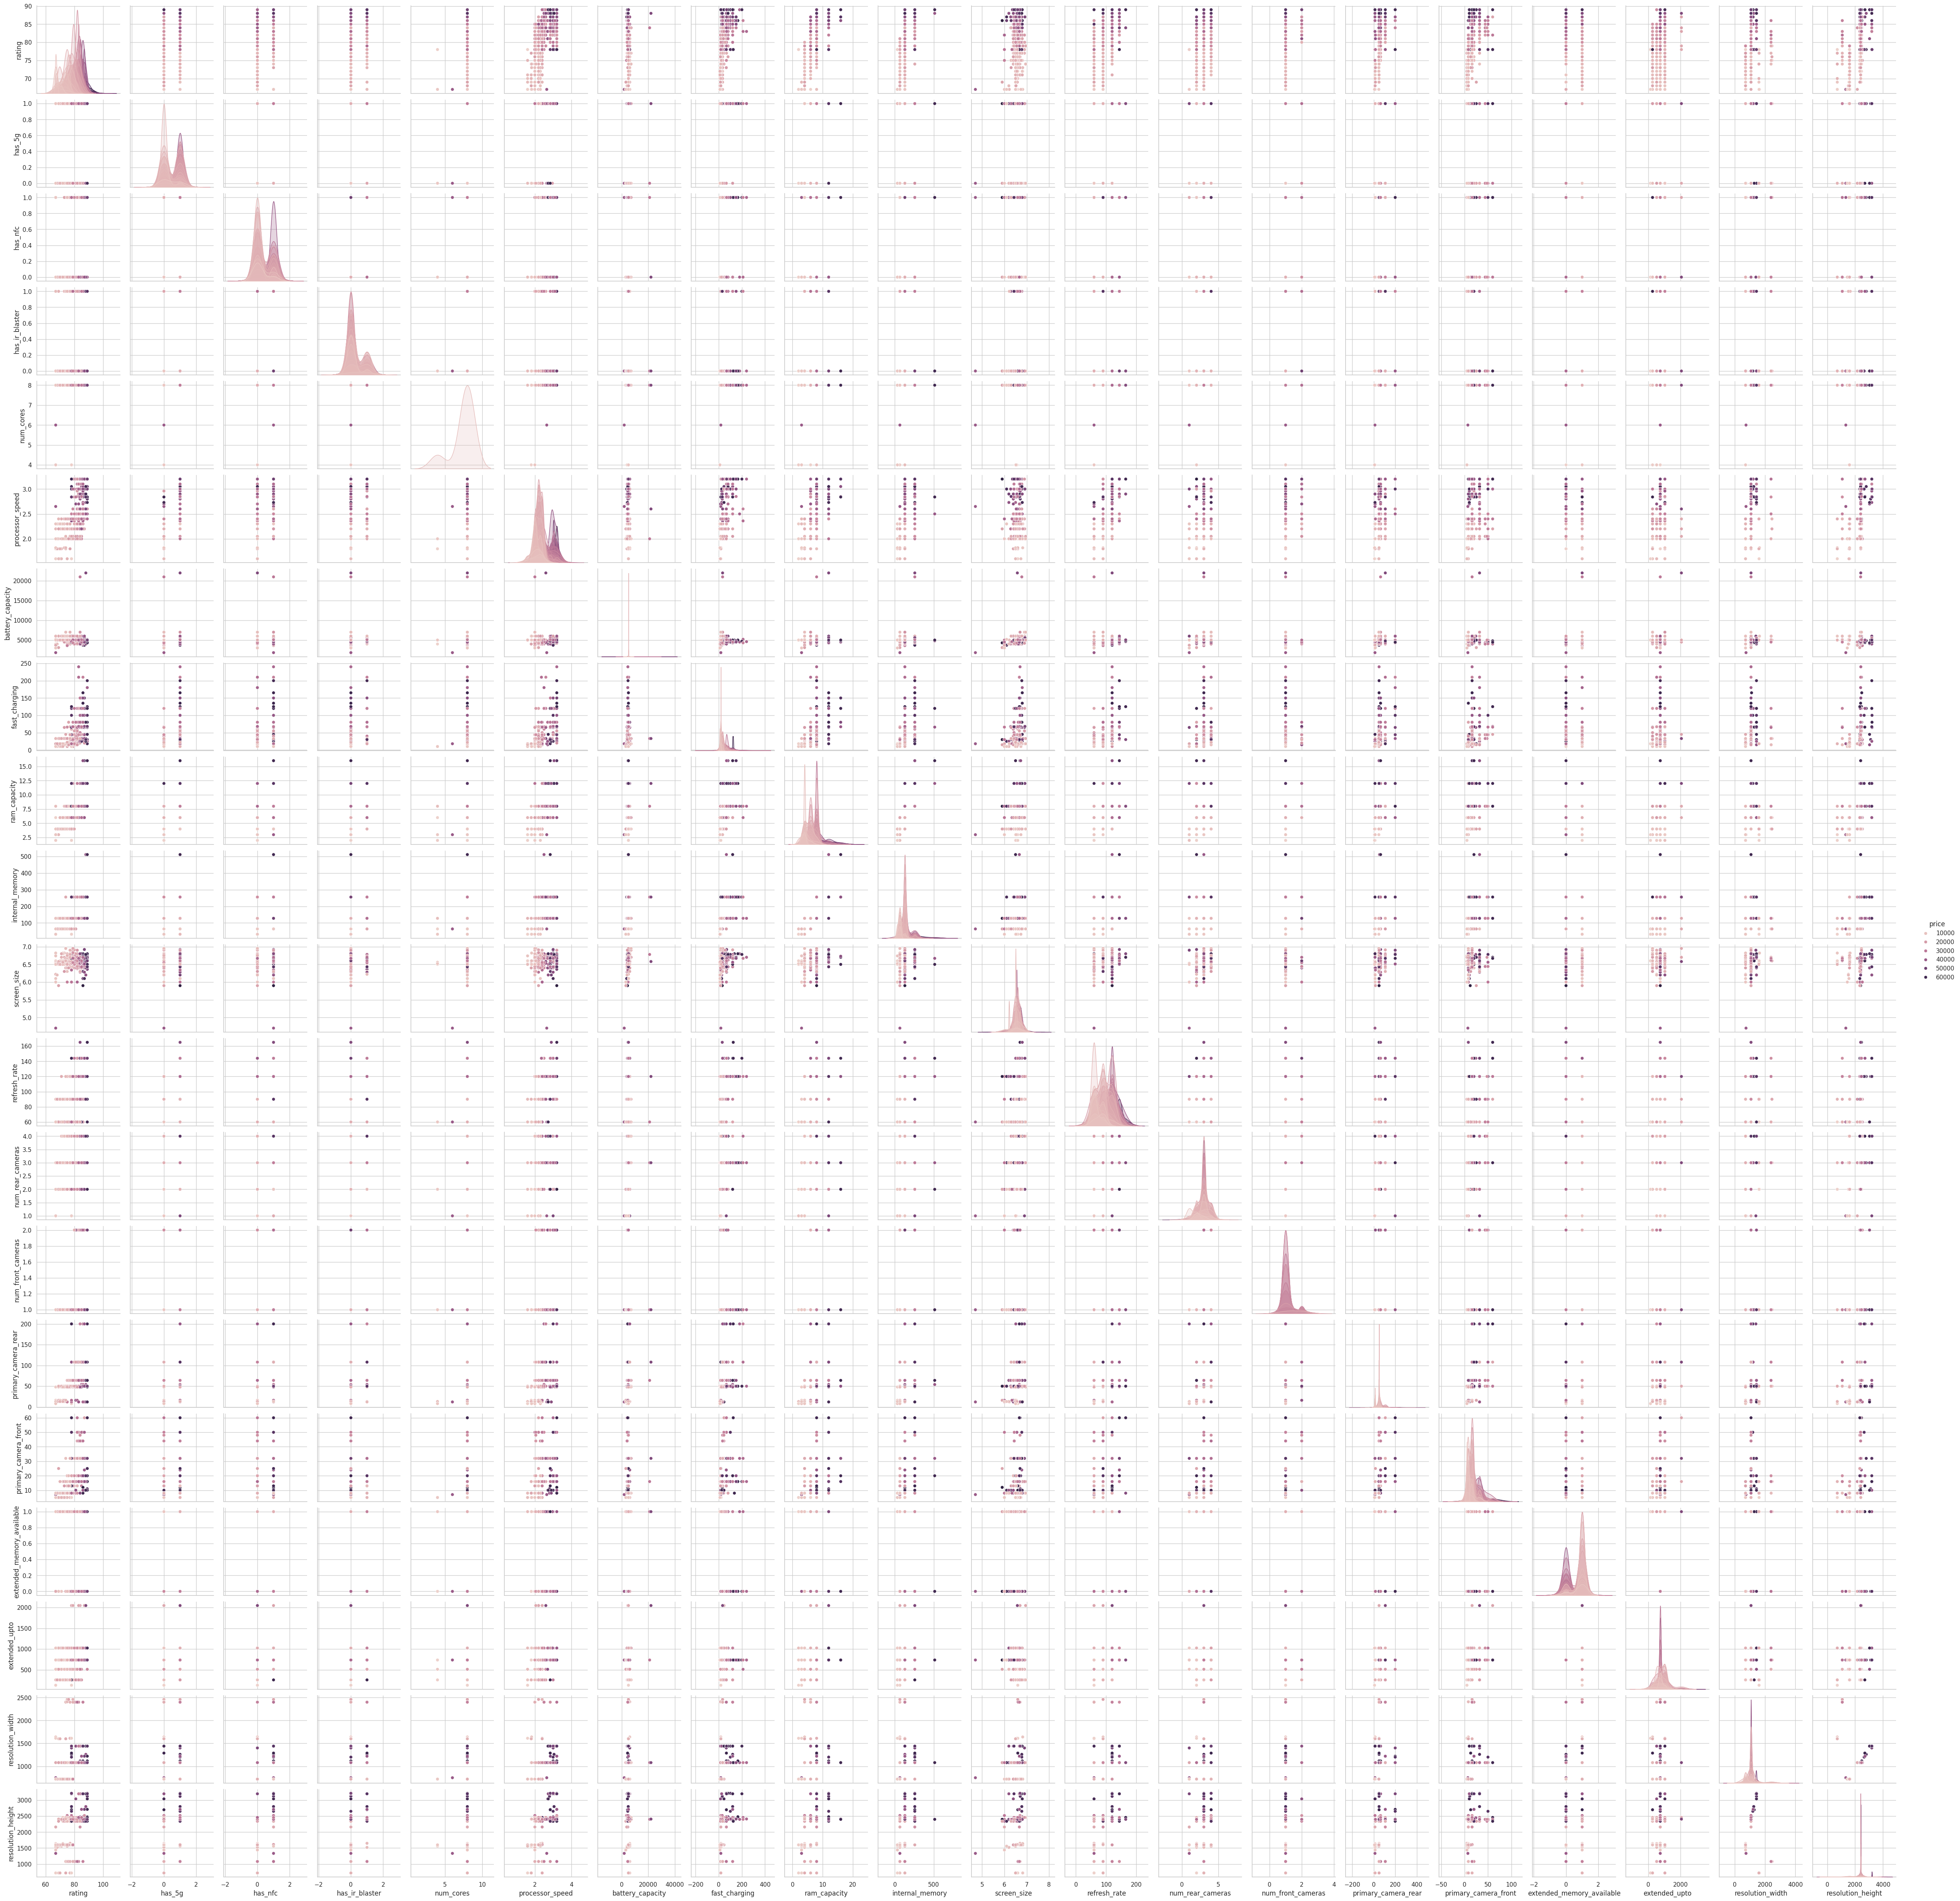

In [233]:
# multivariate analysis
sns.pairplot(df, hue= 'price')
plt.show()

____
# <b><span style='color:orangered'>Step 6.4 |</span><span style='color:maroon'> Correlation between Numerical Features</span></b>


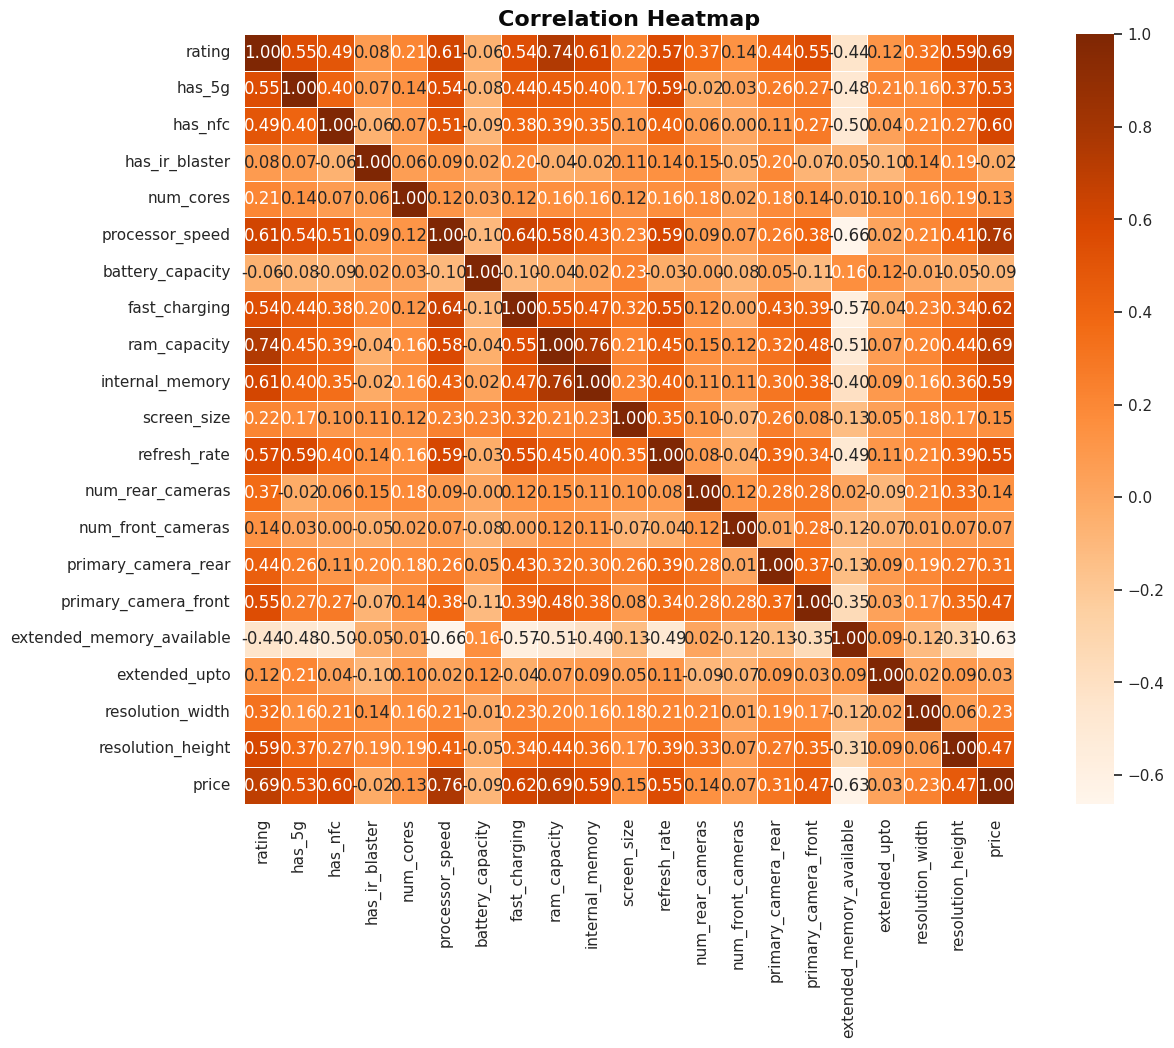

In [234]:

# correlation between numerical features
corr = df.corr(numeric_only=True)
fig = plt.figure(figsize=(16, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='Oranges', cbar=True, square=True, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.show()

<a id="read"></a>
# <p style="background-color:maroon; font-family:calibri; font-size:80%; color:white; text-align:center; border-radius:15px 50px; padding:10px">Step 7 | Applied Machine Learning Model (Regression's)</p>

In [235]:
# Converts categorical feature values (X columns) into numeric values (0, 1, 2, …) so that ML models can understand them.
oe = OrdinalEncoder()
df[['brand_name', 'model', 'processor_brand', 'os']] = oe.fit_transform(df[['brand_name', 'model', 'processor_brand', 'os']]).astype(int)

# Display random 3 samples
df.sample(3)

,brand_name,model,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,battery_capacity,...,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto,resolution_width,resolution_height,price
417,32,360,80,False,False,True,6,8,2.30,5020,...,4,1,0,64,32,1,512,1080.0,2400.0,16490.0
449,25,31,77,False,False,False,4,8,2.05,5000,...,3,1,0,50,16,1,256,1080.0,2412.0,13999.0
53,31,386,86,True,True,False,1,8,3.10,4600,...,3,1,0,50,50,0,736,1080.0,2400.0,35499.0


In [236]:
# Converts target labels (y) or a single categorical column into numeric form.
le = LabelEncoder()
df[['has_5g', 'has_nfc', 'has_ir_blaster']] = df[['has_5g', 'has_nfc', 'has_ir_blaster']].apply(le.fit_transform)
df.sample(3)

,brand_name,model,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,battery_capacity,...,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto,resolution_width,resolution_height,price
164,25,33,79,1,0,0,1,8,2.40,5000,...,3,1,0,48,16,1,1024,1080.0,2400.0,15499.0
95,27,153,84,1,1,0,2,8,2.40,6000,...,4,1,0,50,8,1,1024,1080.0,2400.0,19499.0
444,32,343,82,1,1,1,1,8,2.85,5080,...,3,1,0,64,16,1,1024,1080.0,2460.0,19990.0


In [237]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 675 entries, 0 to 674
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   brand_name                 675 non-null    int64  
 1   model                      675 non-null    int64  
 2   rating                     675 non-null    int64  
 3   has_5g                     675 non-null    int64  
 4   has_nfc                    675 non-null    int64  
 5   has_ir_blaster             675 non-null    int64  
 6   processor_brand            675 non-null    int64  
 7   num_cores                  675 non-null    int64  
 8   processor_speed            675 non-null    float64
 9   battery_capacity           675 non-null    int64  
 10  fast_charging              675 non-null    float64
 11  ram_capacity               675 non-null    int64  
 12  internal_memory            675 non-null    int64  
 13  screen_size                675 non-null    float64
 14  refre

In [238]:
# Define features and label/target variable
X = df.drop('price', axis=1)
y = df['price']

# Split the data into training and testing sets
X_train , X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [239]:
# Standard Scaling of features (normalizes features to have mean = 0 and std = 1 for better ML performance.)
xscaler = StandardScaler()
X_train_s = xscaler.fit_transform(X_train)
X_test_s = xscaler.transform(X_test)

# ******y scaling *****
label_scaler = StandardScaler()
y_train = label_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test = label_scaler.transform(y_test.values.reshape(-1, 1)).flatten()

____
# <b><span style='color:orangered'>Step 7.0 |</span><span style='color:maroon'> Calculate and seve evatution matrices</span></b>

In [280]:
def plot_metrics(name, y_test, y_pred, save=True):
    # Calculate metrics
    r2  = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    metrics = ['R² Score', 'MAE', 'MSE']
    values  = [r2, mae, mse]
    colors  = ['#2563EB', '#DC2626', '#16A34A']

    # ── Global style ──────────────────────────────────────────────────────────
    plt.rcParams.update({
        'text.color':        '#0a0a0a',
        'axes.labelcolor':   '#0a0a0a',
        'xtick.color':       '#0a0a0a',
        'ytick.color':       '#0a0a0a',
        'axes.titlecolor':   '#0a0a0a',
        'font.family':       'DejaVu Sans',
    })

    fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
    fig.patch.set_facecolor('#F8FAFC')
    ax.set_facecolor('#F1F5F9')

    # ── Bars ──────────────────────────────────────────────────────────────────
    x    = np.arange(len(metrics))
    bars = ax.bar(x, values, color=colors, width=0.5,
                  edgecolor='#0a0a0a', linewidth=0.8, zorder=3)

    # ── Grid ──────────────────────────────────────────────────────────────────
    ax.yaxis.grid(True, linestyle='--', linewidth=0.6,
                  color='#94A3B8', alpha=0.7, zorder=0)
    ax.set_axisbelow(True)

    # ── Spines ────────────────────────────────────────────────────────────────
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_color('#475569')
        ax.spines[spine].set_linewidth(1.2)

    # ── Value labels ──────────────────────────────────────────────────────────
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(values) * 0.02,
            f'{val:.4f}',
            ha='center', va='bottom',
            fontsize=11, fontweight='bold', color='#0a0a0a'
        )

    # ── Labels & title ────────────────────────────────────────────────────────
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=12, fontweight='bold', color='#0a0a0a')
    ax.tick_params(axis='y', labelsize=10, colors='#0a0a0a')
    ax.set_xlabel('Evaluation Metrics', fontsize=13, fontweight='bold',
                  labelpad=10, color='#0a0a0a')
    ax.set_ylabel('Score', fontsize=13, fontweight='bold',
                  labelpad=10, color='#0a0a0a')
    ax.set_title(f'{name} — Model Performance', fontsize=15,
                 fontweight='bold', color='#0a0a0a', pad=16)

    # ── Legend ────────────────────────────────────────────────────────────────
    patches = [mpatches.Patch(color=c, label=m) for c, m in zip(colors, metrics)]
    ax.legend(handles=patches, fontsize=10, framealpha=0.9,
              edgecolor='#CBD5E1', facecolor='#F8FAFC',
              labelcolor='#0a0a0a', loc='upper right')

    ax.set_ylim(0, max(values) * 1.18)
    plt.tight_layout()

    # Save model as high quality image acceptable in IEEE journal and conference papers
    # ── Save BEFORE plt.show() clears the figure ──────────────────────────────
    if save:
        filename = f"model_{name.replace(' ', '_')}_performance.png"
        fig.savefig(filename,
                    dpi=600,
                    bbox_inches='tight',
                    format='png',
                    facecolor='white',      # ← forces white background on save
                    edgecolor='none')
        print(f"✅ Saved → {filename}")

    plt.show()

____
# <b><span style='color:orangered'>Step 7.1 |</span><span style='color:maroon'> Linear Regression</span></b>

In [282]:
# Linear Regression
lr = LinearRegression()

# Train the Linear Regression model
lr.fit(X_train, y_train)

# Make predictions
y_pred = lr.predict(X_test)

# Evaluate the model 
print('R2 Score', round(r2_score(y_test, y_pred), 4))
print('mean_absolute_error', round(mean_absolute_error(y_test, y_pred), 4))
print('mean_squared_error', round(mean_squared_error(y_test, y_pred), 4))

R2 Score 0.7385
mean_absolute_error 0.3608
mean_squared_error 0.251


✅ Saved → model_Linear_Regression_performance.png


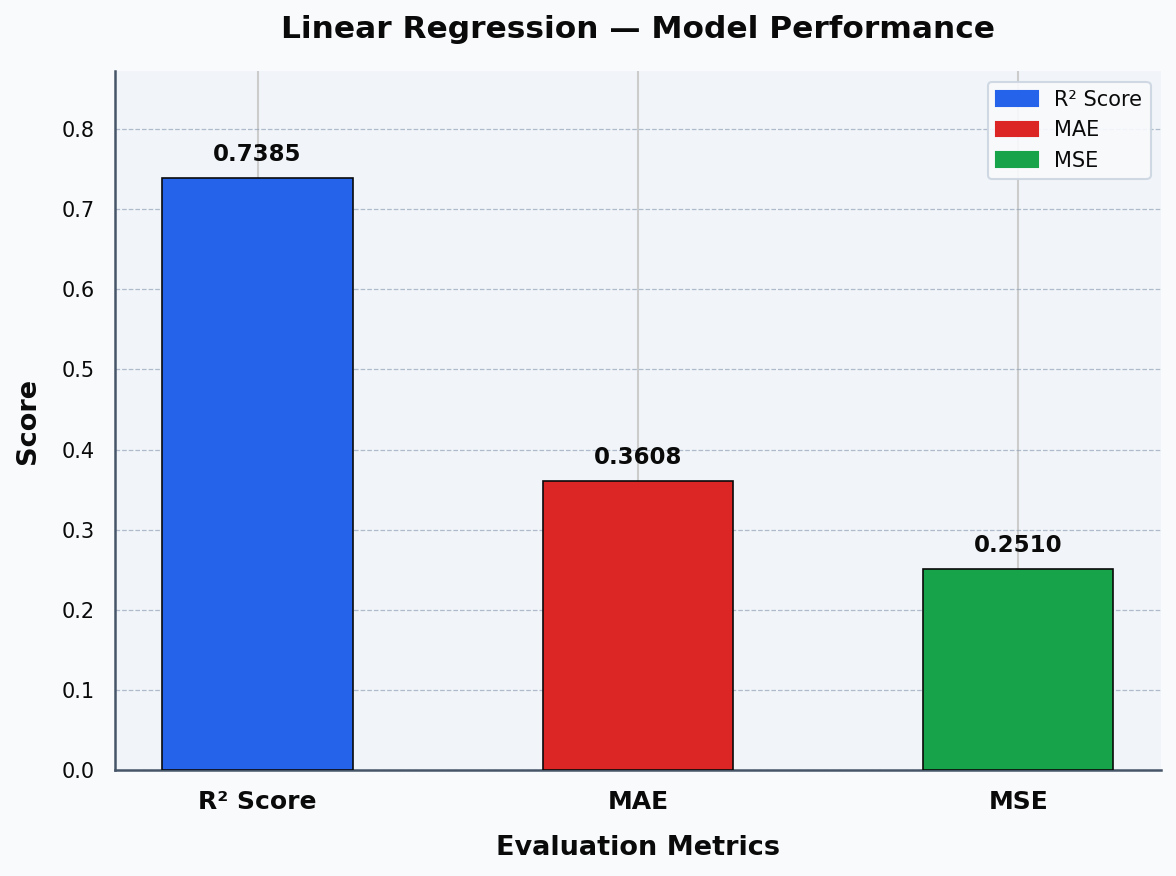

In [283]:
plot_metrics(name = 'Linear Regression', y_test=y_test, y_pred=y_pred)

____
# <b><span style='color:orangered'>Step 7.2 |</span><span style='color:maroon'> Decision Tree Regression</span></b>

In [284]:
# Decision Tree Regressor
dt = DecisionTreeRegressor(random_state=42)

# Train the Decision Tree Regressor
dt.fit(X_train, y_train)

# Make predictions
y_pred = dt.predict(X_test)

# Evaluate the model
print('R2 Score', round(r2_score(y_test, y_pred), 4))
print('mean_absolute_error', round(mean_absolute_error(y_test, y_pred), 4))
print('mean_squared_error', round(mean_squared_error(y_test, y_pred), 4))


R2 Score 0.7207
mean_absolute_error 0.3368
mean_squared_error 0.2681


✅ Saved → model_Decision_Tree_Regressor_performance.png


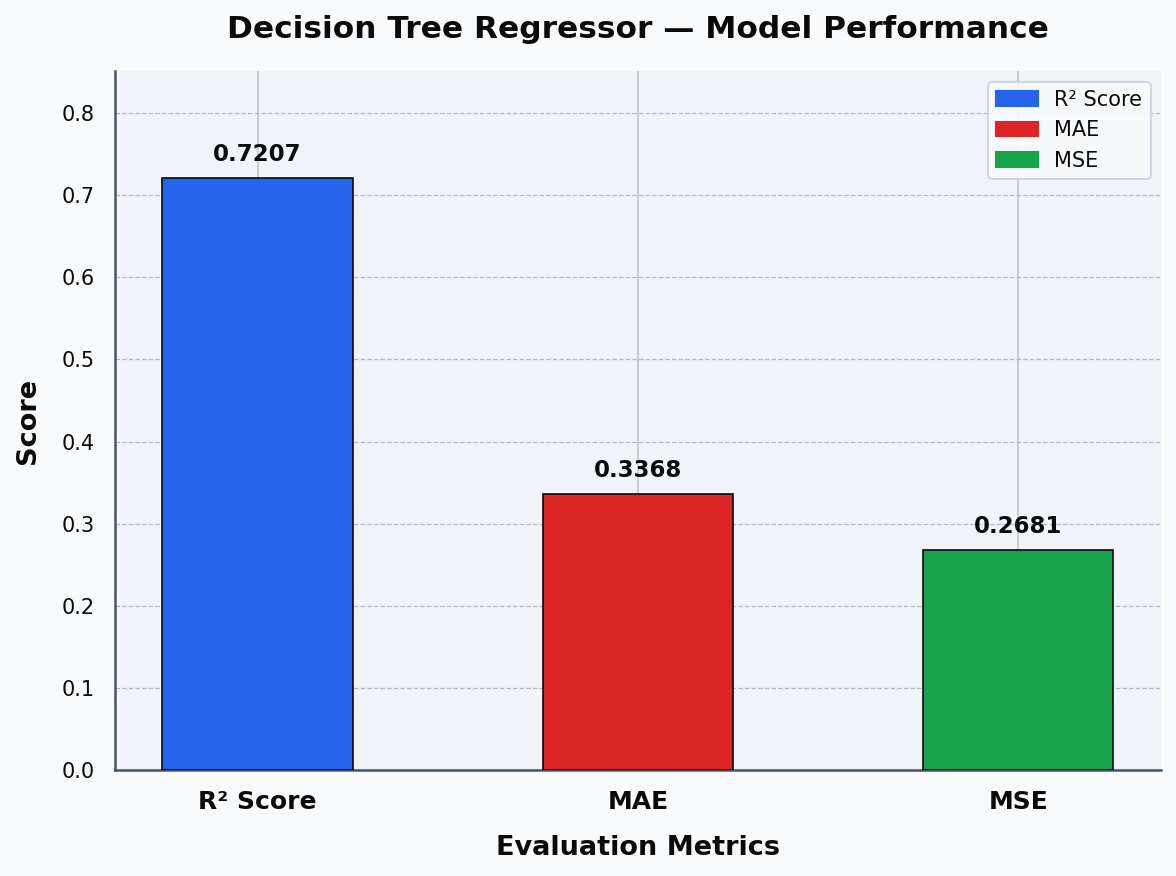

In [285]:
plot_metrics(name = 'Decision Tree Regressor', y_test=y_test, y_pred=y_pred)

____
# <b><span style='color:orangered'>Step 7.3 |</span><span style='color:maroon'> K-Nearest Neighbors (KNN) Regression</span></b>

In [286]:
# K-Nearest Neighbors Regressor
knn = KNeighborsRegressor(n_neighbors=5)

# Train the KNN Regressor
knn.fit(X_train, y_train)

# Make predictions
y_pred = knn.predict(X_test)

# Evaluate the model
print('R2 Score', round(r2_score(y_test, y_pred), 4))
print('mean_absolute_error', round(mean_absolute_error(y_test, y_pred), 4))
print('mean_squared_error', round(mean_squared_error(y_test, y_pred), 4))

R2 Score 0.6154
mean_absolute_error 0.4222
mean_squared_error 0.3692


✅ Saved → model_KNN_performance.png


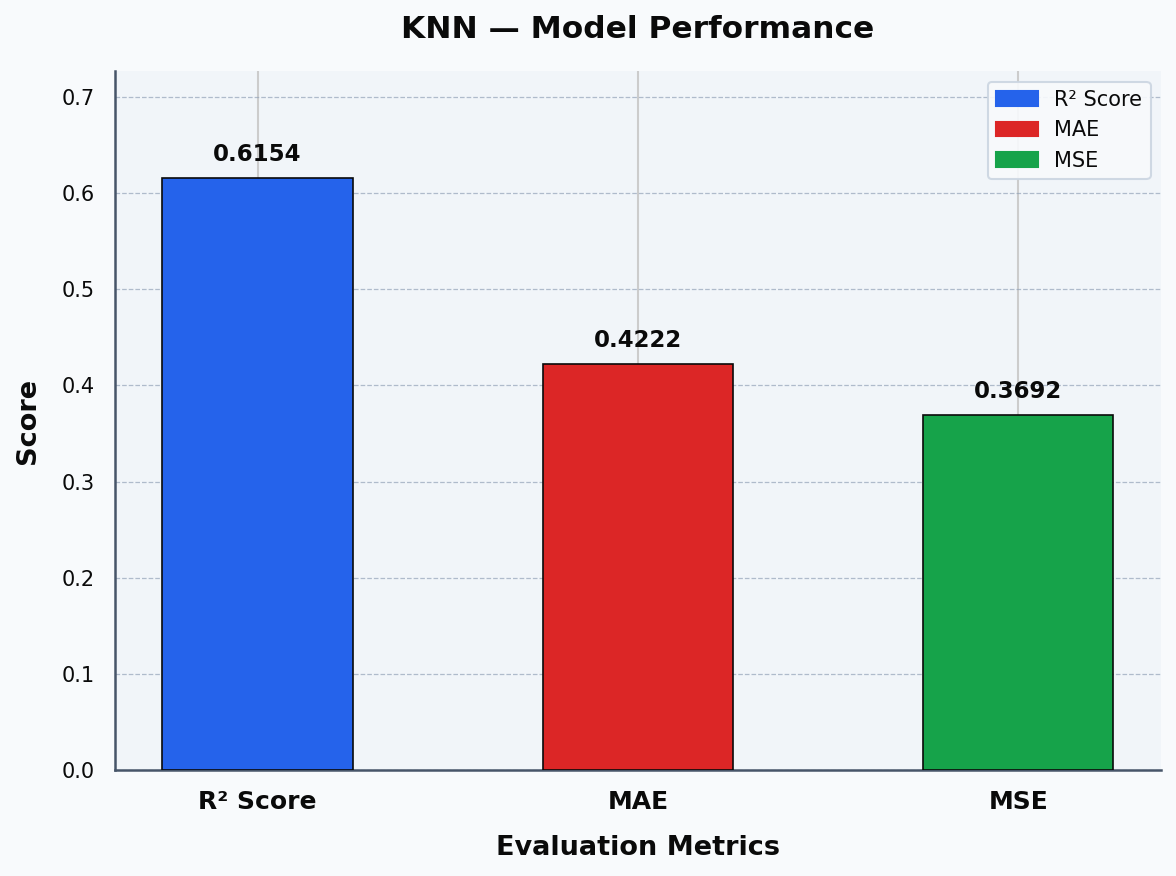

In [287]:
plot_metrics(name = 'KNN', y_test=y_test, y_pred=y_pred)

____
# <b><span style='color:orangered'>Step 7.4 |</span><span style='color:maroon'> Bagging Regressor</span></b>

In [288]:
# Bagging Regressor
bag = BaggingRegressor(n_estimators=100, random_state=42)

# Train the Bagging Regressor
bag.fit(X_train, y_train)

# Make predictions
y_pred = bag.predict(X_test)

# Evaluate the model
print('R2 Score', round(r2_score(y_test, y_pred), 4))
print('mean_absolute_error', round(mean_absolute_error(y_test, y_pred), 4))
print('mean_squared_error', round(mean_squared_error(y_test, y_pred), 4))

R2 Score 0.8815
mean_absolute_error 0.2336
mean_squared_error 0.1138


✅ Saved → model_Bagging_Regressor_performance.png


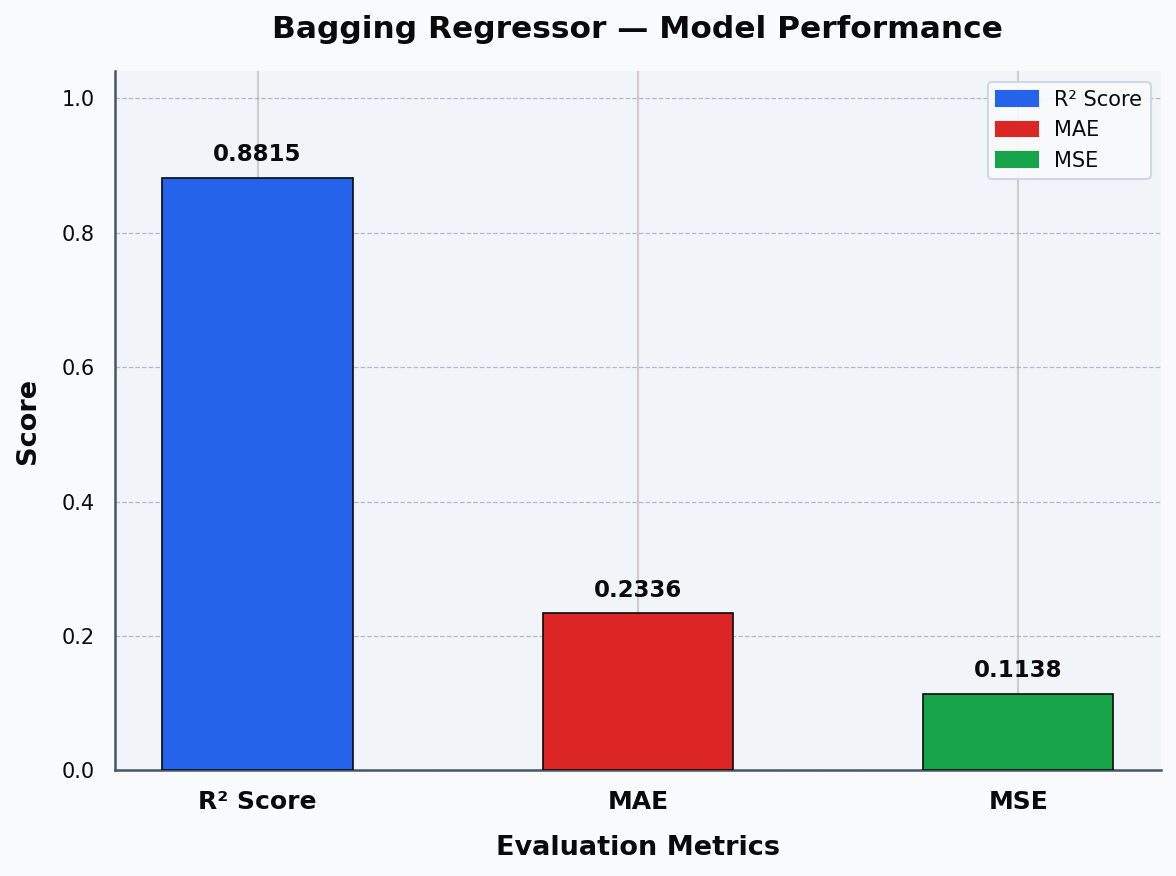

In [289]:
plot_metrics(name = 'Bagging Regressor', y_test=y_test, y_pred=y_pred)

____
# <b><span style='color:orangered'>Step 7.5 |</span><span style='color:maroon'> Random Forest Regressor</span></b>

In [290]:
# Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the Random Forest Regressor
rf.fit(X_train, y_train)

# Make predictions
y_pred = rf.predict(X_test)

# Evaluate the model
print('R2 Score', round(r2_score(y_test, y_pred), 4))
print('mean_absolute_error', round(mean_absolute_error(y_test, y_pred), 4))
print('mean_squared_error', round(mean_squared_error(y_test, y_pred), 4))

R2 Score 0.883
mean_absolute_error 0.2316
mean_squared_error 0.1123


✅ Saved → model_Random_Forest_Regressor_performance.png


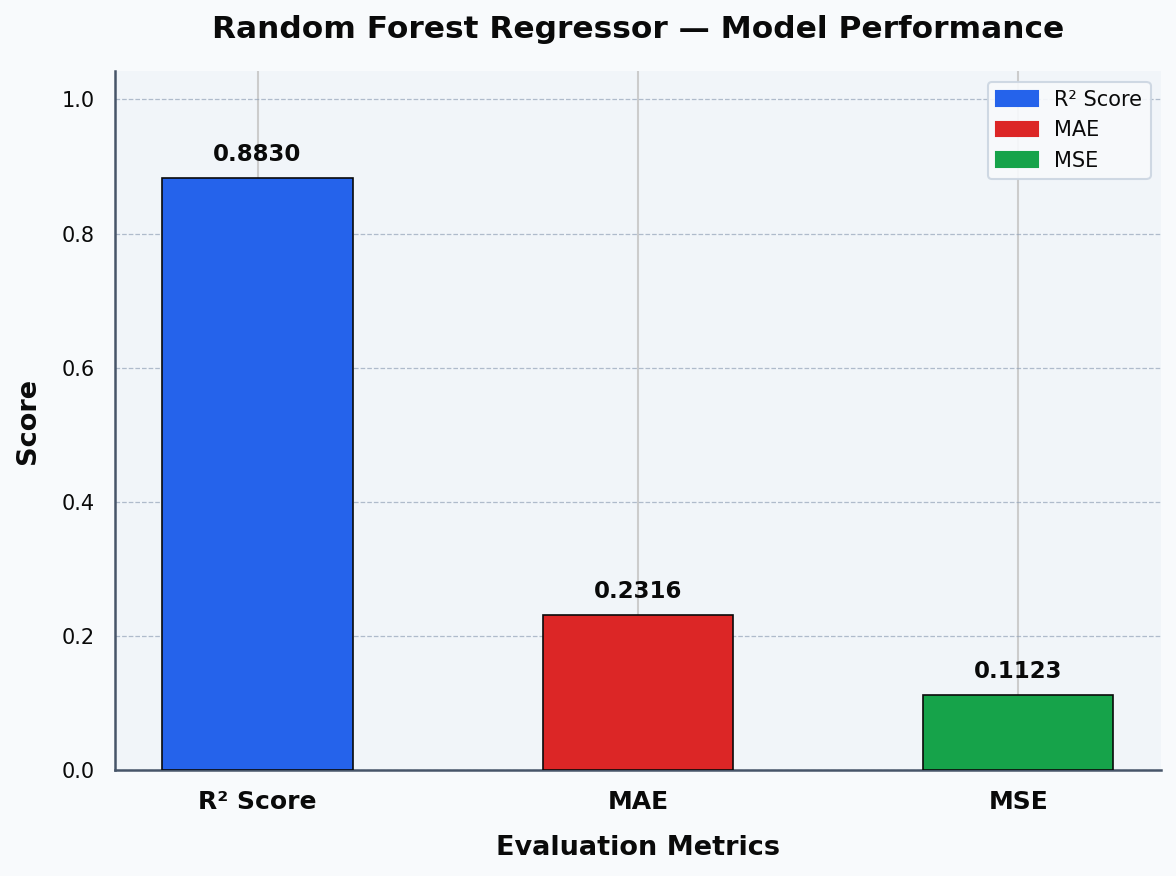

In [291]:
plot_metrics(name = 'Random Forest Regressor', y_test=y_test, y_pred=y_pred)

____
# <b><span style='color:orangered'>Step 7.6 |</span><span style='color:maroon'> LightGBM Regressor</span></b>

In [292]:
# LightGBM (Light Gradient Boosting Machine) Regressor
lgbm = lgb.LGBMRegressor(n_estimators=100, random_state=42)

# Train the LightGBM Regressor
lgbm.fit(X_train, y_train)

# Make predictions
y_pred = lgbm.predict(X_test)

# Evaluate the model
print('R2 Score', round(r2_score(y_test, y_pred), 4))
print('mean_absolute_error', round(mean_absolute_error(y_test, y_pred), 4))
print('mean_squared_error', round(mean_squared_error(y_test, y_pred), 4))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000096 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 424
[LightGBM] [Info] Number of data points in the train set: 540, number of used features: 21
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

✅ Saved → model_LightGBM_performance.png


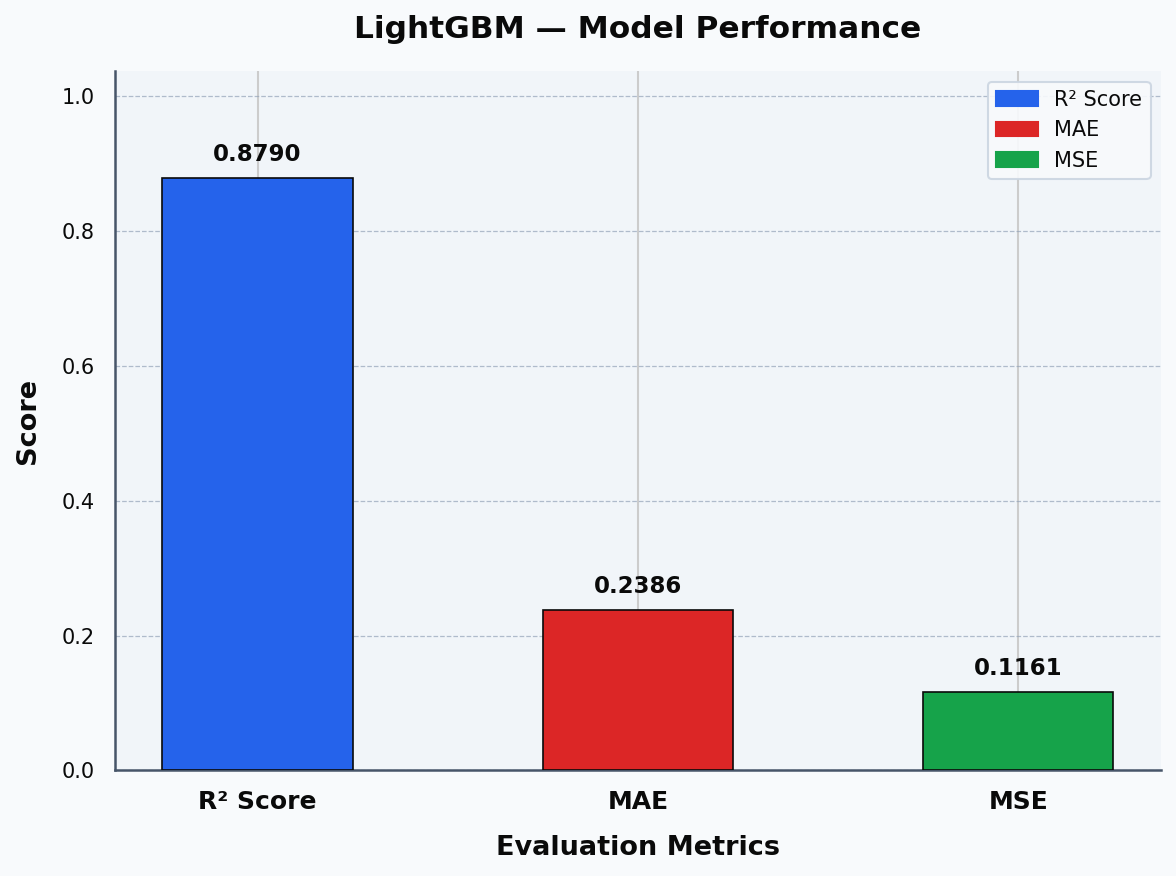

In [293]:
plot_metrics(name = 'LightGBM', y_test=y_test, y_pred=y_pred)

____
# <b><span style='color:orangered'>Step 7.7 |</span><span style='color:maroon'> Stacking Regressor</span></b>

In [294]:
# Stacking Regressor
st = StackingRegressor(estimators=[
    ('lr', LinearRegression()),
    ('dt', DecisionTreeRegressor(random_state=42)),
    ('svr', SVR(kernel='linear', C=100, gamma=0.1, epsilon=.1))
], final_estimator=RandomForestRegressor(n_estimators=100, random_state=42))

# Train the Stacking Regressor
st.fit(X_train, y_train)

# Make predictions
y_pred = st.predict(X_test)

# Evaluate the model
print('R2 Score:', round(r2_score(y_test, y_pred), 4))
print('mean_absolute_error:', round(mean_absolute_error(y_test, y_pred), 4))
print('mean_squared_error:', round(mean_squared_error(y_test, y_pred), 4))

R2 Score: 0.8356
mean_absolute_error: 0.2825
mean_squared_error: 0.1578


✅ Saved → model_Stacking_Regressor_performance.png


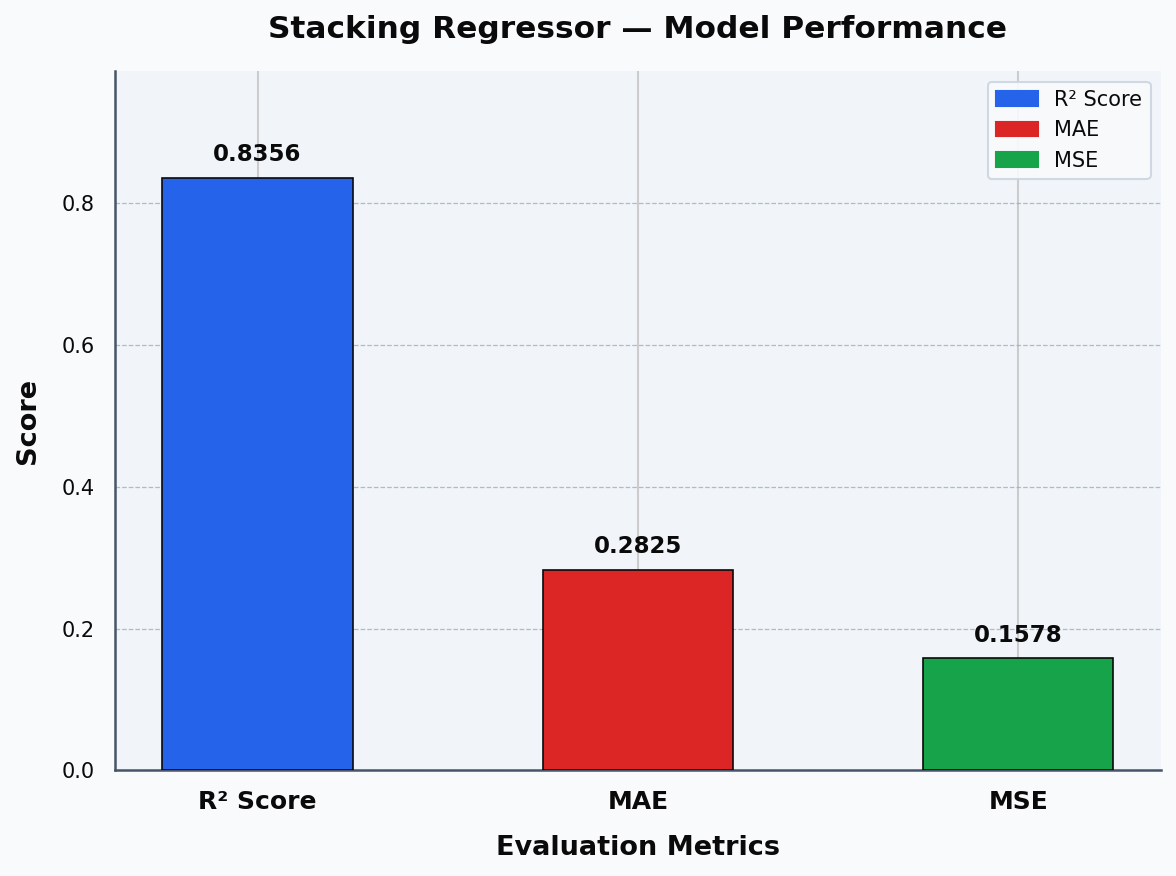

In [295]:
plot_metrics(name = 'Stacking Regressor', y_test=y_test, y_pred=y_pred)

____
# <b><span style='color:orangered'>Step 7.8 |</span><span style='color:maroon'> AdaBoost Regressor</span></b>

In [296]:
# AdaBoost Regressor
ada = AdaBoostRegressor(n_estimators=100, random_state=42)

# Train the AdaBoost Regressor
ada.fit(X_train, y_train)

# Make predictions
y_pred = ada.predict(X_test)

# Evaluate the model
print('R2 Score:', round(r2_score(y_test, y_pred), 4))
print('mean_absolute_error:', round(mean_absolute_error(y_test, y_pred), 4))
print('mean_squared_error:', round(mean_squared_error(y_test, y_pred), 4))


R2 Score: 0.7992
mean_absolute_error: 0.3738
mean_squared_error: 0.1928


✅ Saved → model_AdaBoost_Regressor_performance.png


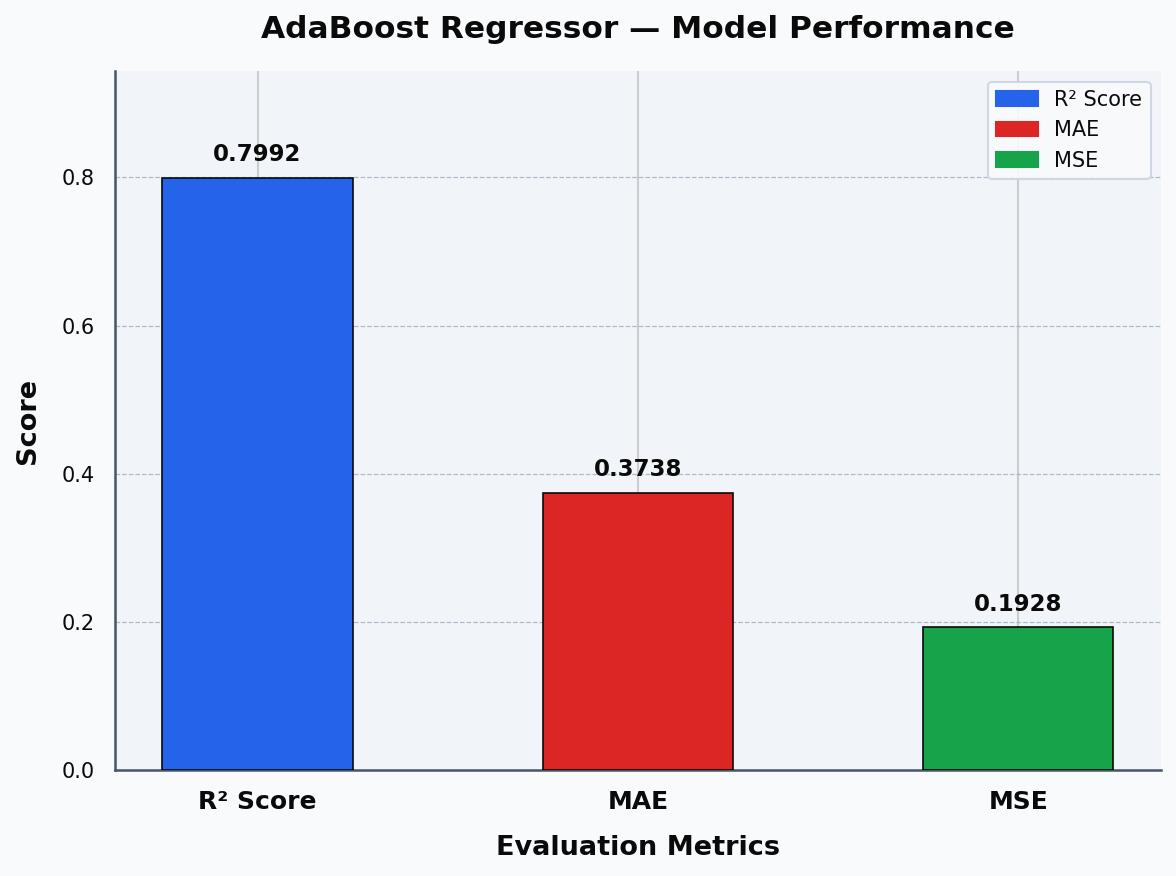

In [297]:
plot_metrics(name = 'AdaBoost Regressor', y_test=y_test, y_pred=y_pred)

____
# <b><span style='color:orangered'>Step 7.9 |</span><span style='color:maroon'> Gradient Boosting Regressor</span></b>

In [298]:
# Gradient Boosting Regressor
gbr = GradientBoostingRegressor(n_estimators=100, random_state=42)

# Train the Gradient Boosting Regressor
gbr.fit(X_train, y_train)

# Make predictions
y_pred = gbr.predict(X_test)

# Evaluate the model
print('R2 Score:', round(r2_score(y_test, y_pred), 4))
print('mean_absolute_error:', round(mean_absolute_error(y_test, y_pred), 4))
print('mean_squared_error:', round(mean_squared_error(y_test, y_pred), 4))

R2 Score: 0.8741
mean_absolute_error: 0.2413
mean_squared_error: 0.1209


✅ Saved → model_Gradient_Boosting_Regressor_performance.png


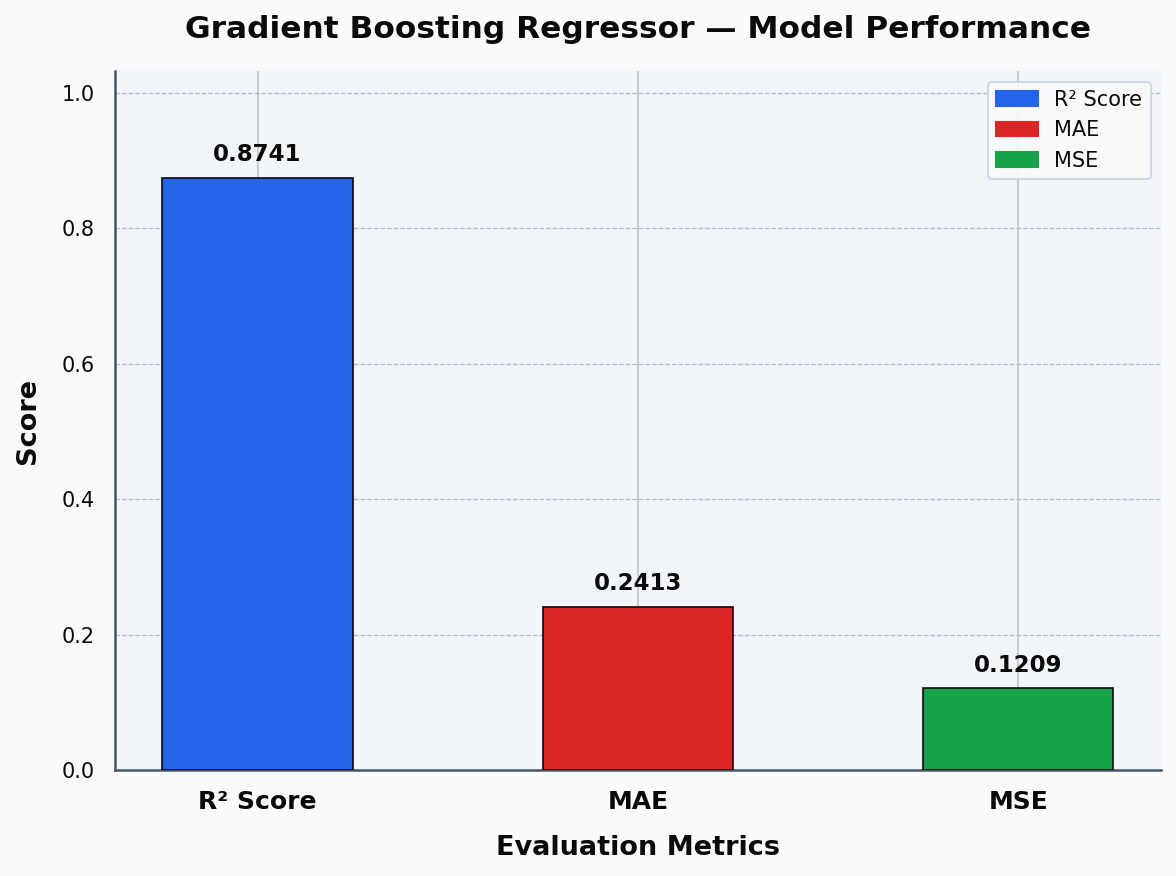

In [299]:
plot_metrics(name = 'Gradient Boosting Regressor', y_test=y_test, y_pred=y_pred)

# <b><span style='color:orangered'>Step 7.10 |</span><span style='color:maroon'> Extra Trees Regressor</span></b>

In [300]:
# Extra Trees Regressor
etr = ExtraTreesRegressor(n_estimators=184, max_depth=12)

# Train the Extra Trees Regressor
etr.fit(X_train, y_train)

# Make predictions
y_pred = etr.predict(X_test)



# Evaluate the model
print('R2 Score', round(r2_score(y_test, y_pred), 4))
print('mean_absolute_error', round(mean_absolute_error(y_test, y_pred), 4))
print('mean_squared_error', round(mean_squared_error(y_test, y_pred), 4))


R2 Score 0.8879
mean_absolute_error 0.2243
mean_squared_error 0.1076


✅ Saved → model_Extra_Trees_Regressor_performance.png


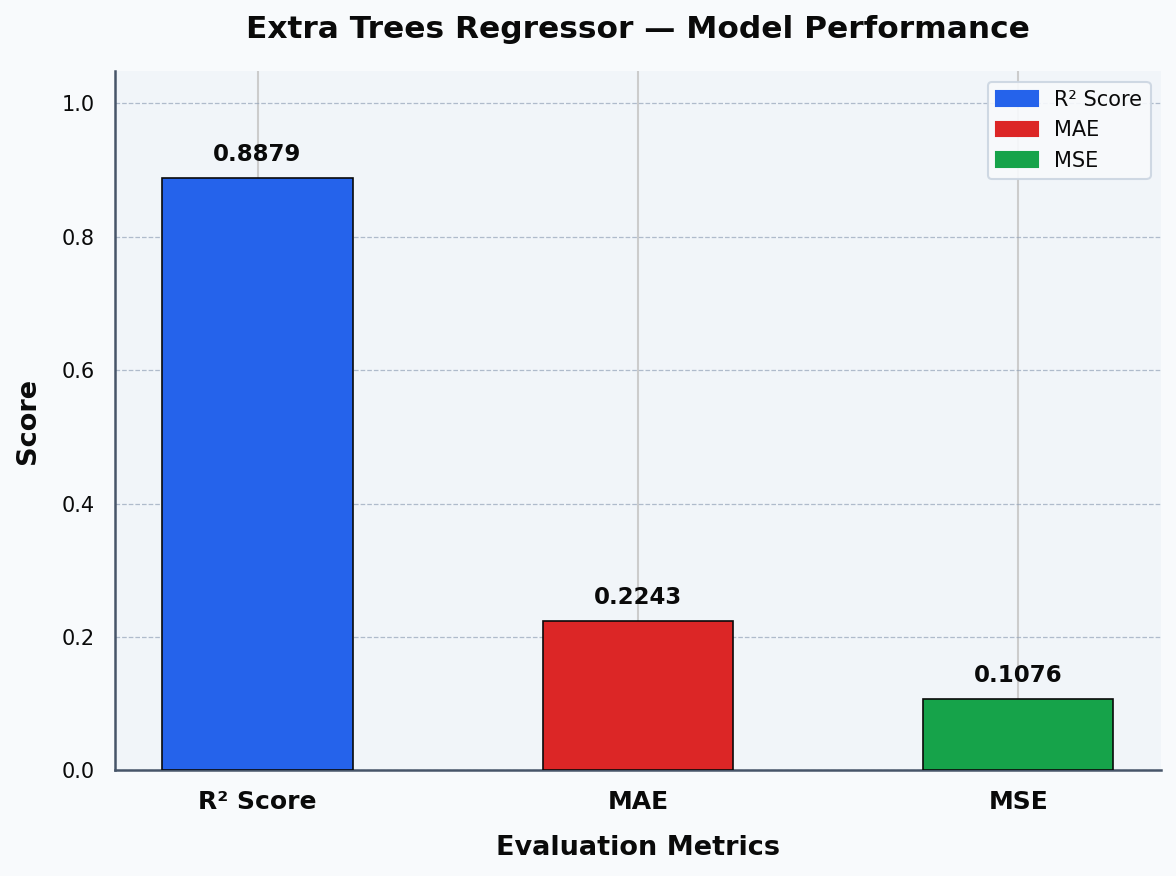

In [301]:
plot_metrics(name = 'Extra Trees Regressor', y_test=y_test, y_pred=y_pred)

____
# <b><span style='color:orangered'>Step 7.11 |</span><span style='color:maroon'> XGBoost Regressor</span></b>

In [302]:
# XGBoost Regressor
xgbr = xgb.XGBRegressor(objective ='reg:squarederror', n_estimators=263, max_depth= 6, learning_rate=0.09877118752852476, random_state=42)

# Train the XGBoost Regressor
xgbr.fit(X_train, y_train)

# Make predictions
y_pred = xgbr.predict(X_test)

# Evaluate the model
print('R2 Score', round(r2_score(y_test, y_pred), 4))
print('mean_absolute_error', round(mean_absolute_error(y_test, y_pred), 4))
print('mean_squared_error', round(mean_squared_error(y_test, y_pred), 4))
pickle.dump(xgbr, open('smartphone_price_model1.pkl', 'wb'))

R2 Score 0.9013
mean_absolute_error 0.2102
mean_squared_error 0.0948


✅ Saved → model_XGBoost_Regressor_performance.png


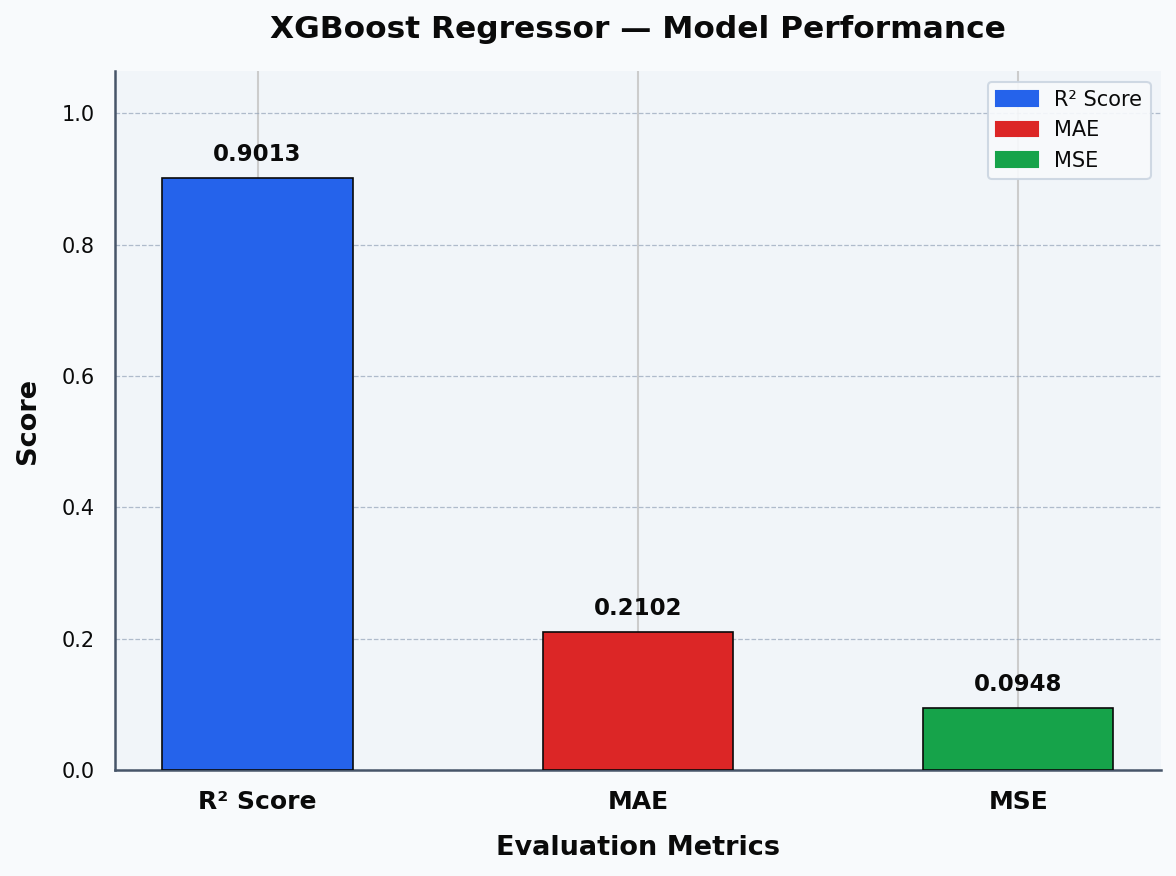

In [303]:
plot_metrics(name = 'XGBoost Regressor', y_test=y_test, y_pred=y_pred)

____
# <b><span style='color:orangered'>Step 7.12 |</span><span style='color:maroon'> CatBoost Regressor</span></b>

In [304]:
# CatBoost regression model
catbr = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=6, random_seed=42, verbose=0)

# Train the CatBoost Regressor
catbr.fit(X_train, y_train)

# Make predictions
y_pred = catbr.predict(X_test)

# Evaluate the model
print('R2 Score', round(r2_score(y_test, y_pred), 4))
print('mean_absolute_error', round(mean_absolute_error(y_test, y_pred), 4))
print('mean_squared_error', round(mean_squared_error(y_test, y_pred), 4))

R2 Score 0.8659
mean_absolute_error 0.2265
mean_squared_error 0.1287


✅ Saved → model_CatBoost_Regressor_performance.png


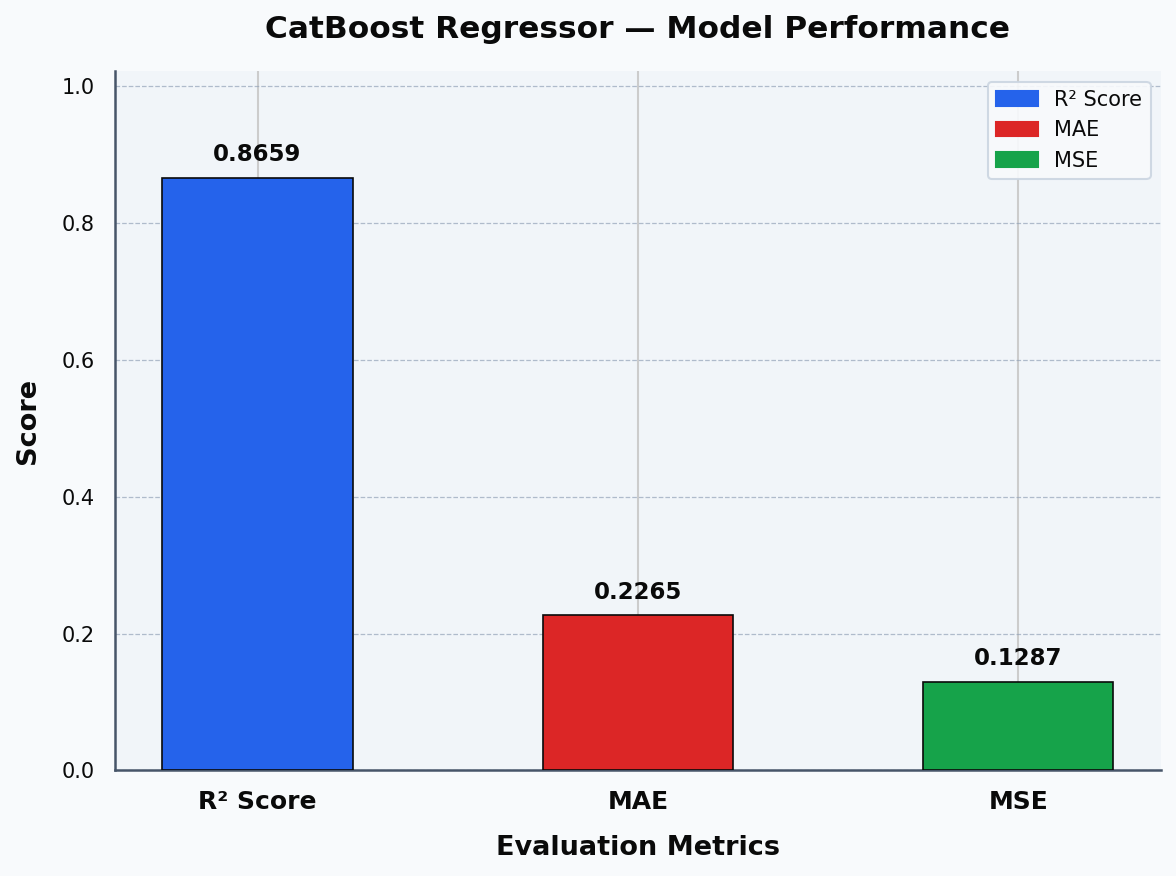

In [305]:
plot_metrics(name = 'CatBoost Regressor', y_test=y_test, y_pred=y_pred)

____
# <b><span style='color:orangered'>Step 7.13 |</span><span style='color:maroon'> ElasticNet Regression</span></b>

In [306]:
# ElasticNet Regression
enet = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42)

# Train the ElasticNet Regression model
enet.fit(X_train, y_train)

# Make predictions
y_pred = enet.predict(X_test)

# Evaluate the model
print("ElasticNet Regression")
print("R2 Score:", round(r2_score(y_test, y_pred), 4))
print("mean_absolute_error:", round(mean_absolute_error(y_test, y_pred), 4))
print("mean_squared_error:", round(mean_squared_error(y_test, y_pred), 4))
print("--------------------------------------")


ElasticNet Regression
R2 Score: 0.5748
mean_absolute_error: 0.4545
mean_squared_error: 0.4082
--------------------------------------


✅ Saved → model_ElasticNet_Recursion_performance.png


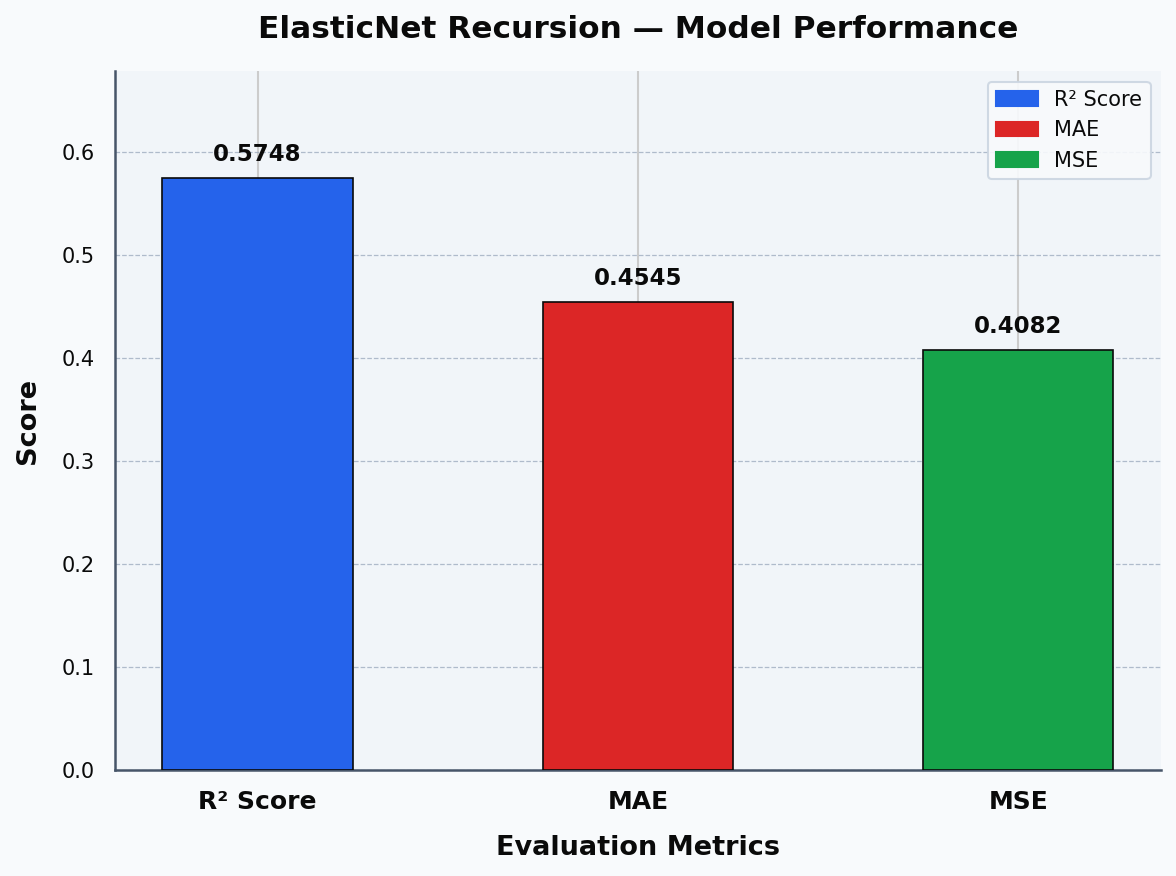

In [307]:
plot_metrics(name = 'ElasticNet Recursion', y_test=y_test, y_pred=y_pred)

____
# <b><span style='color:orangered'>Step 7.14 |</span><span style='color:maroon'> Lasso Regression</span></b>

In [308]:
# Lasso Regression
lasso = Lasso(alpha=1.0, random_state=42)

# Train the Lasso Regression model
lasso.fit(X_train, y_train)

# Make predictions
y_pred = lasso.predict(X_test)

# Evaluate the model
print("Lasso Regression")
print("R2 Score:", round(r2_score(y_test, y_pred), 4))
print("mean_absolute_error:", round(mean_absolute_error(y_test, y_pred), 4))
print("mean_squared_error:", round(mean_squared_error(y_test, y_pred), 4))
print("--------------------------------------")


Lasso Regression
R2 Score: 0.5518
mean_absolute_error: 0.472
mean_squared_error: 0.4303
--------------------------------------


✅ Saved → model_Lasso_Regression_performance.png


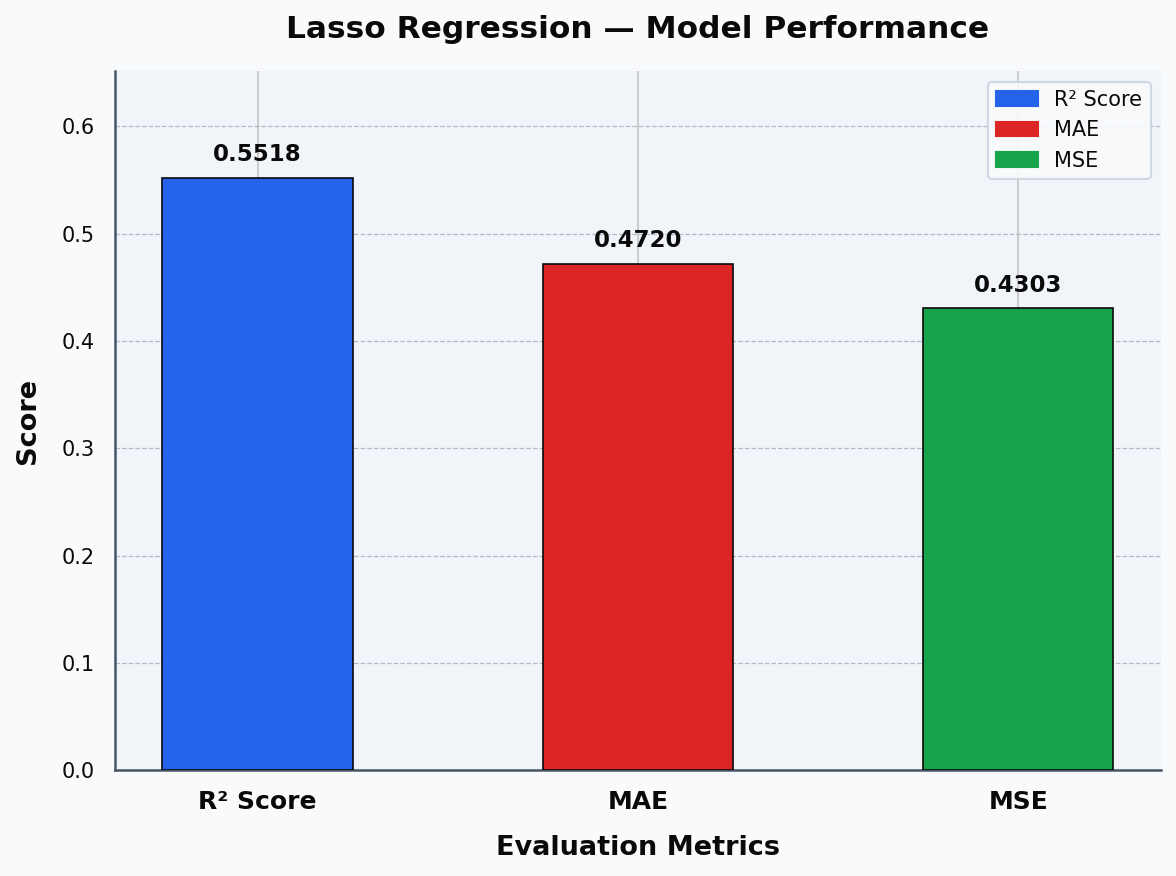

In [309]:
plot_metrics(name = 'Lasso Regression', y_test=y_test, y_pred=y_pred)

____
# <b><span style='color:orangered'>Step 7.15 |</span><span style='color:maroon'> Ridge Regression</span></b>

In [310]:
# Ridge Regression
ridge = Ridge(alpha=1.0, random_state=42)

# Train the Ridge Regression model
ridge.fit(X_train, y_train)

# Make predictions
y_pred = ridge.predict(X_test)

# Evaluate the model
print("Ridge Regression")
print("R2 Score:", round(r2_score(y_test, y_pred), 4))
print("mean_absolute_error:", round(mean_absolute_error(y_test, y_pred), 4))
print("mean_squared_error:", round(mean_squared_error(y_test, y_pred), 4))
print("--------------------------------------")


Ridge Regression
R2 Score: 0.7404
mean_absolute_error: 0.3593
mean_squared_error: 0.2492
--------------------------------------


✅ Saved → model_Ridge_Regression_performance.png


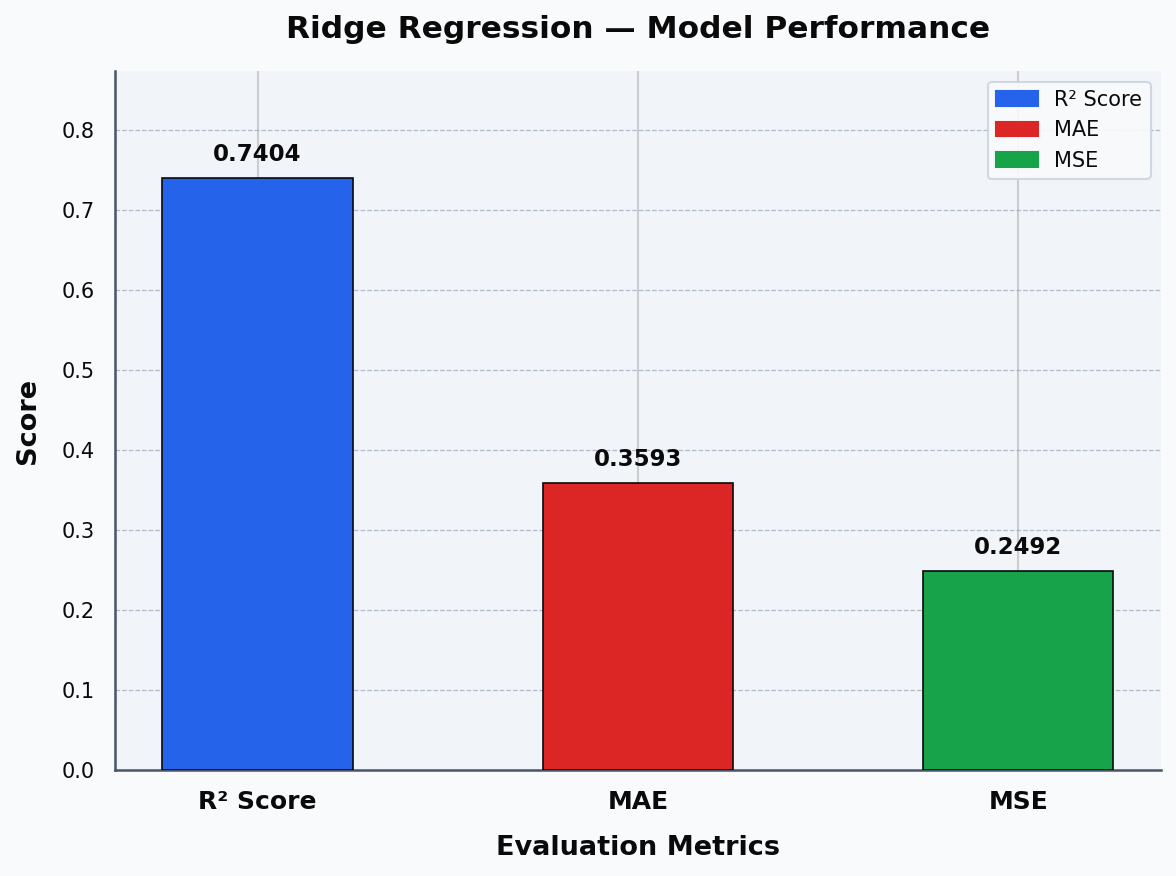

In [311]:
plot_metrics(name = 'Ridge Regression', y_test=y_test, y_pred=y_pred)

____
# <b><span style='color:orangered'>Step 7.16 |</span><span style='color:maroon'> Huber Regression</span></b>

In [312]:
# Huber Regressor
huber = HuberRegressor()

# Train the Huber Regressor model
huber.fit(X_train, y_train)

# Make predictions
y_pred = huber.predict(X_test)

# Evaluate the model
print("Huber Regressor")
print("R2 Score:", round(r2_score(y_test, y_pred), 4))
print("mean_absolute_error:", round(mean_absolute_error(y_test, y_pred), 4))
print("mean_squared_error:", round(mean_squared_error(y_test, y_pred), 4))
print("--------------------------------------")


Huber Regressor
R2 Score: 0.5075
mean_absolute_error: 0.4633
mean_squared_error: 0.4728
--------------------------------------


/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


✅ Saved → model_Huber_Regressor_performance.png


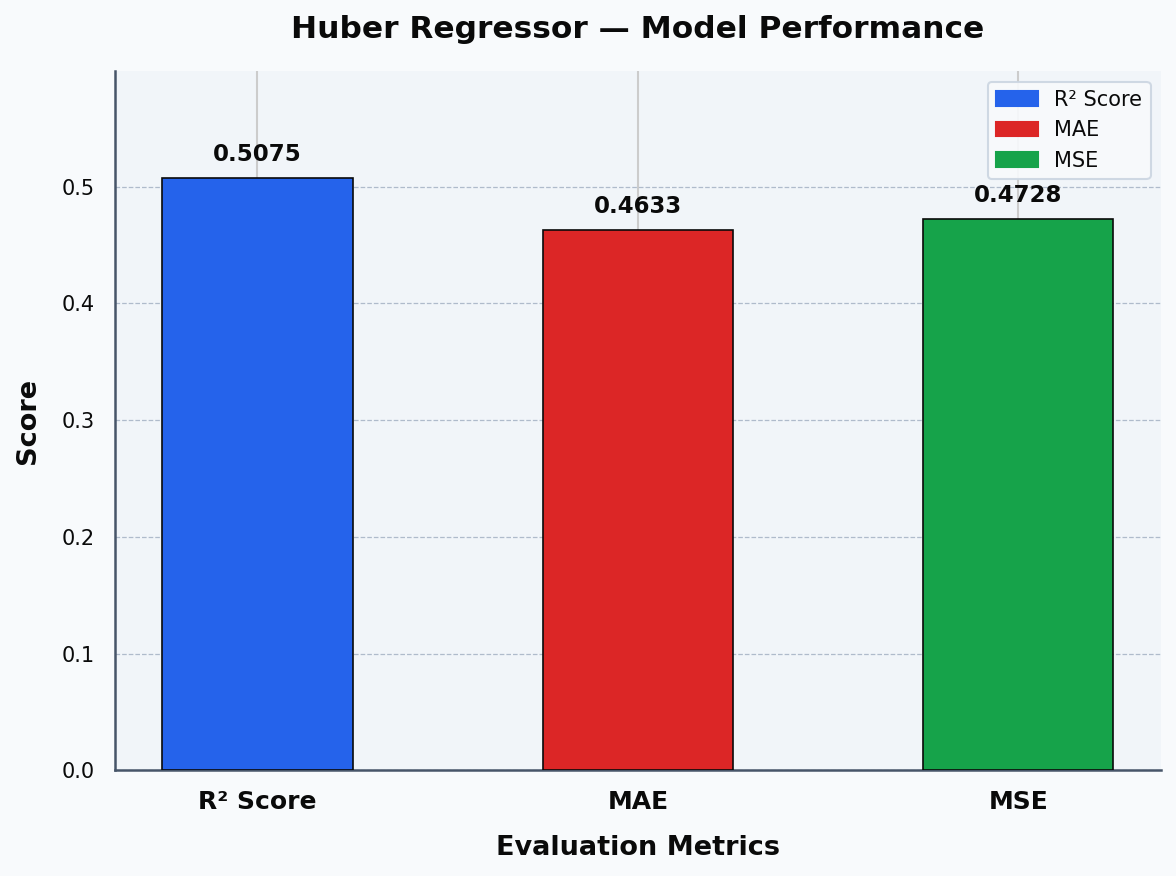

In [313]:
plot_metrics(name = 'Huber Regressor', y_test=y_test, y_pred=y_pred)

____
# <b><span style='color:orangered'>Step 7.17 |</span><span style='color:maroon'> Kernel Ridge Regressor</span></b>

In [314]:
# Kernel Ridge Regression

# Scale data
scaler = StandardScaler()

# Fit and transform the training data, transform the test data
X_train_s = scaler.fit_transform(X_train)

# Transform the test data
X_test_s = scaler.transform(X_test)

# Create and train the Kernel Ridge Regression model
krr = KernelRidge(kernel='rbf')
krr.fit(X_train_s, y_train)

# Make predictions
y_pred = krr.predict(X_test_s)

# Evaluate the model
print("Kernel Ridge Regression")
print("R2 Score:", round(r2_score(y_test, y_pred), 4))
print("mean_absolute_error:", round(mean_absolute_error(y_test, y_pred), 4))
print("mean_squared_error:", round(mean_squared_error(y_test, y_pred), 4))
print("--------------------------------------")


Kernel Ridge Regression
R2 Score: 0.8098
mean_absolute_error: 0.2947
mean_squared_error: 0.1826
--------------------------------------


✅ Saved → model_Kernel_Ridge_Regressor_performance.png


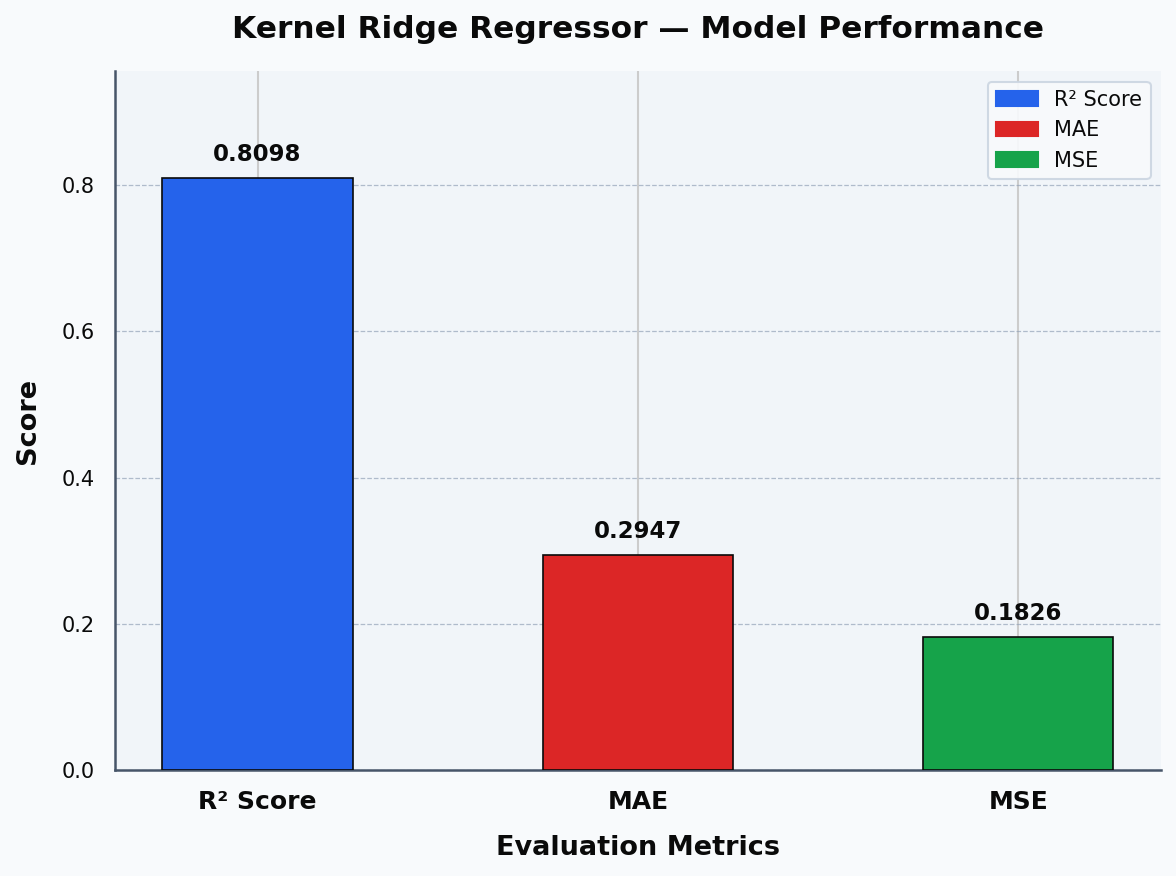

In [315]:
plot_metrics(name = 'Kernel Ridge Regressor', y_test=y_test, y_pred=y_pred)

____
# <b><span style='color:orangered'>Step 7.18 |</span><span style='color:maroon'> Multi-Layer Perceptron Regressor</span></b>

In [316]:
# Multi-Layer Perceptron Regressor (Neural Network)
mlp = MLPRegressor(hidden_layer_sizes=(128, 64), activation='relu',
                   solver='adam', max_iter=1000, random_state=42)

# Train the MLP Regressor model
mlp.fit(X_train_s, y_train)

# Make predictions
y_pred = mlp.predict(X_test_s)

# Evaluate the model
print("MLP Regressor (Neural Network)")
print("R2 Score:", round(r2_score(y_test, y_pred), 4))
print("mean_absolute_error:", round(mean_absolute_error(y_test, y_pred), 4))
print("mean_squared_error:", round(mean_squared_error(y_test, y_pred), 4))
print("--------------------------------------")


MLP Regressor (Neural Network)
R2 Score: 0.8458
mean_absolute_error: 0.263
mean_squared_error: 0.1481
--------------------------------------


✅ Saved → model_MLP_Regressor_performance.png


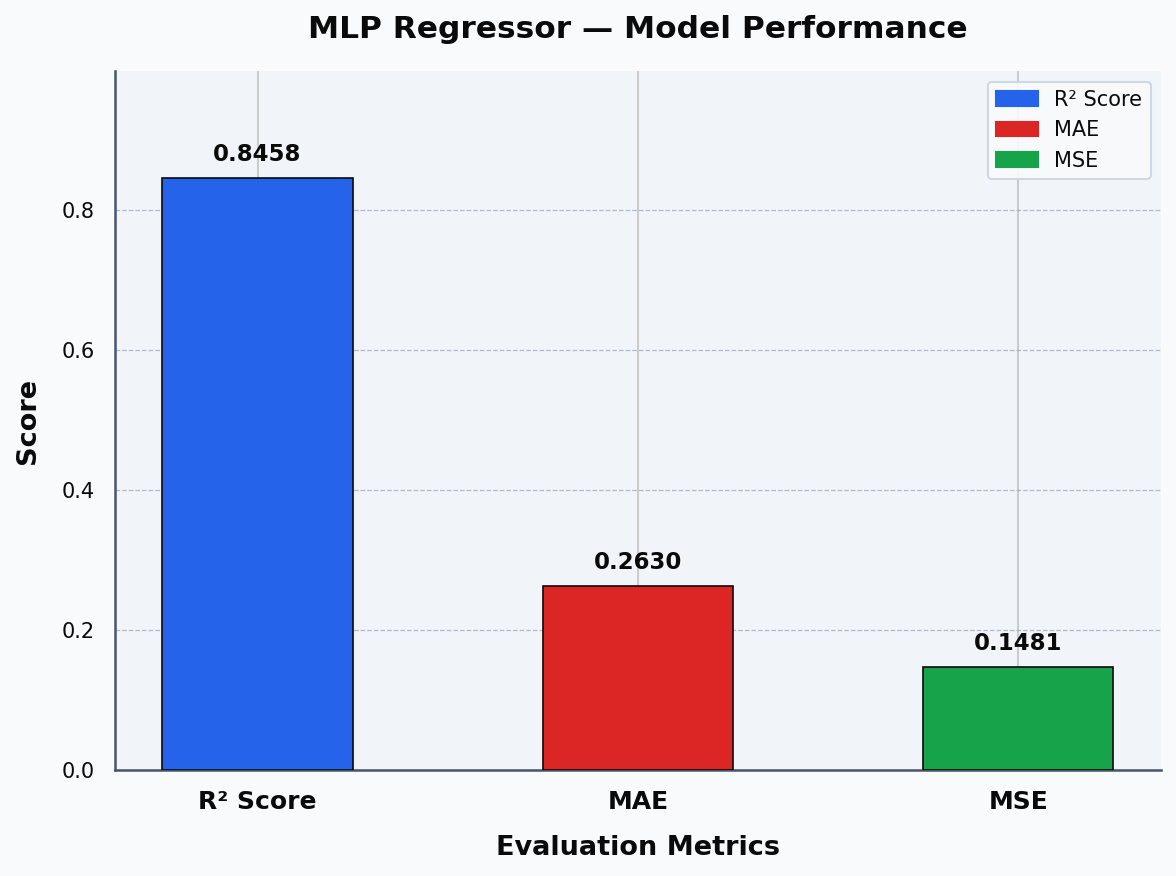

In [317]:
plot_metrics(name = 'MLP Regressor', y_test=y_test, y_pred=y_pred)

<a id="read"></a>
# <p style="background-color:maroon; font-family:calibri; font-size:80%; color:white; text-align:center; border-radius:15px 50px; padding:10px">Step 8 | Model Selection and Comparison</p>

____
# <b><span style='color:orangered'>Step 8.1 |</span><span style='color:maroon'> Model Selection</span></b>

<div style="border-radius:10px; border:#8B0000 solid; padding:15px; background-color:#FAF3F3; font-size:100%; text-align:left; color:#222;">
  <h3 align="left" style="color:#8B0000;">Model Selection Using Optuna</h3>
  <p style="margin:6px 0 0; line-height:1.6;">
    Using <strong>Optuna</strong> for hyperparameter optimization, we have to compare several top models for Mobile Price Prediction given bellow:
  </p>
  <ul style="margin:6px 0 0; line-height:1.6;">
    <li>Bagging Regressor</li>
    <li>Random Forest Regressor</li>
    <li>Gradient Boosting Regressor</li>
    <li>Extra Trees Regressor</li>
    <li>XGBoost Regressor</li>
    <li>CatBoost Regressor etc.</li>
  </ul>
  </pre>
</div>


In [327]:
# OPTUNA HYPERPARAMETER TUNING (Make sour by runing this cell multiple time evry time you will get diffrenct parameters and model but we select the best model only by rnning multiple time)

# Objective Function
def objective(trial):

    model_name = trial.suggest_categorical(
        "model", 
        ["Bagging", "RandomForest", "GradientBoosting", "ExtraTrees", "XGBoost", "CatBoost"]
    )

    # -------------------- BAGGING --------------------
    if model_name == "Bagging":
        n_estimators = trial.suggest_int("n_estimators", 50, 300)
        max_samples = trial.suggest_float("max_samples", 0.5, 1.0)

        model = BaggingRegressor(
            n_estimators=n_estimators,
            max_samples=max_samples,
            random_state=42
        )

    # -------------------- RANDOM FOREST --------------------
    elif model_name == "RandomForest":
        n_estimators = trial.suggest_int("n_estimators", 50, 300)
        max_depth = trial.suggest_int("max_depth", 3, 30)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)

        model = RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            random_state=42
        )

    # -------------------- GRADIENT BOOSTING --------------------
    elif model_name == "GradientBoosting":
        n_estimators = trial.suggest_int("n_estimators", 50, 300)
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3)
        max_depth = trial.suggest_int("max_depth", 2, 10)

        model = GradientBoostingRegressor(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            random_state=42
        )

    # -------------------- EXTRA TREES --------------------
    elif model_name == "ExtraTrees":
        n_estimators = trial.suggest_int("n_estimators", 50, 300)
        max_depth = trial.suggest_int("max_depth", 3, 30)

        model = ExtraTreesRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=42
        )

    # -------------------- XGBOOST --------------------
    elif model_name == "XGBoost":
        n_estimators = trial.suggest_int("n_estimators", 50, 300)
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3)
        max_depth = trial.suggest_int("max_depth", 3, 15)

        model = xgb.XGBRegressor(
            objective="reg:squarederror",
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            random_state=42
        )

    # -------------------- CATBOOST --------------------
    elif model_name == "CatBoost":
        iterations = trial.suggest_int("iterations", 200, 1200)
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3)
        depth = trial.suggest_int("depth", 4, 10)

        model = CatBoostRegressor(
            iterations=iterations,
            learning_rate=learning_rate,
            depth=depth,
            random_seed=42,
            verbose=0
        )

    # -------------------- TRAIN --------------------
    model.fit(X_train, y_train)

    # -------------------- VALIDATE --------------------
    predictions = model.predict(X_test)
    loss = mean_absolute_error(y_test, predictions)   # For Optuna
    return loss


# Run Optuna Study
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

# -------------------- FINAL BEST MODEL --------------------
best_model_name = study.best_trial.params["model"]
best_params = study.best_params

# Recreate best model
if best_model_name == "Bagging":
    model = BaggingRegressor(
        n_estimators=best_params["n_estimators"],
        max_samples=best_params["max_samples"],
        random_state=42
    )
elif best_model_name == "RandomForest":
    model = RandomForestRegressor(
        n_estimators=best_params["n_estimators"],
        max_depth=best_params["max_depth"],
        min_samples_split=best_params["min_samples_split"],
        random_state=42
    )
elif best_model_name == "GradientBoosting":
    model = GradientBoostingRegressor(
        n_estimators=best_params["n_estimators"],
        learning_rate=best_params["learning_rate"],
        max_depth=best_params["max_depth"],
        random_state=42
    )
elif best_model_name == "ExtraTrees":
    model = ExtraTreesRegressor(
        n_estimators=best_params["n_estimators"],
        max_depth=best_params["max_depth"],
        random_state=42
    )
elif best_model_name == "XGBoost":
    model = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=best_params["n_estimators"],
        learning_rate=best_params["learning_rate"],
        max_depth=best_params["max_depth"],
        random_state=42
    )
elif best_model_name == "CatBoost":
        model = CatBoostRegressor(
        iterations=best_params["iterations"],
        learning_rate=best_params["learning_rate"],
        depth=best_params["depth"],
        random_seed=42,
        verbose=0
    )

# Train best model on full training data
model.fit(X_train, y_train)
predictions = model.predict(X_test)

# Calculate Metrics
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
accuracy = r2_score(y_test, predictions)

# -------------------- PRINT RESULTS --------------------
print("Best Model:", best_model_name)
print("Best Parameters:", best_params)
print("Best Score (MAE):", study.best_value)
print("MAE:", round(mae, 4))
print("MSE:", round(mse, 4))
print("Accuracy (R²):", round(accuracy, 4))

[I 2026-04-04 21:21:54,471] A new study created in memory with name: no-name-b5dfe1f1-d1e6-4d34-ba1d-532c40c0c8fd


[I 2026-04-04 21:21:57,132] Trial 0 finished with value: 0.2413596216330474 and parameters: {'model': 'CatBoost', 'iterations': 680, 'learning_rate': 0.05433313391796704, 'depth': 10}. Best is trial 0 with value: 0.2413596216330474.
[I 2026-04-04 21:21:57,734] Trial 1 finished with value: 0.23714198299274578 and parameters: {'model': 'Bagging', 'n_estimators': 230, 'max_samples': 0.6125274950728361}. Best is trial 1 with value: 0.23714198299274578.
[I 2026-04-04 21:21:58,571] Trial 2 finished with value: 0.2337504846335582 and parameters: {'model': 'Bagging', 'n_estimators': 262, 'max_samples': 0.8604187730935213}. Best is trial 2 with value: 0.2337504846335582.
[I 2026-04-04 21:21:58,924] Trial 3 finished with value: 0.24615035995309578 and parameters: {'model': 'RandomForest', 'n_estimators': 179, 'max_depth': 10, 'min_samples_split': 17}. Best is trial 2 with value: 0.2337504846335582.
[I 2026-04-04 21:21:59,187] Trial 4 finished with value: 0.2591357073377971 and parameters: {'mode

Best Model: CatBoost
Best Parameters: {'model': 'CatBoost', 'iterations': 842, 'learning_rate': 0.10283562131943272, 'depth': 7}
Best Score (MAE): 0.21493247151334882
MAE: 0.2149
MSE: 0.1125
Accuracy (R²): 0.8828


<div
  style="border-radius:10px; border:#8B0000 solid; padding:15px; background-color:#FAF3F3; font-size:100%; text-align:left; color:#222;">
  <h3 align="left" style="color:#8B0000;">Optuna Hyperparameter Tuning</h3>
  <p style="margin:6px 0 0; line-height:1.6;">
    After running <strong>Optuna</strong> for hyperparameter optimization, the experiment identified the 
    <strong>XGBoost Regressor</strong> as the most accurate model for the Mobile Price Prediction project.
  </p>
  
  <hr style="border:1px solid #8B0000; margin:10px 0;">

  <h4 style="color:#8B0000;">Best Performing Model</h4>
  <p style="margin:4px 0 0; line-height:1.6;">
    <strong>XGBoost Regressor</strong>
  </p>
  
  <hr style="border:1px solid #8B0000; margin:10px 0;">

  <h4 style="color:#8B0000;">Best Parameters Selected by Optuna</h4>
  <pre style="background-color:#fff; padding:10px; border-radius:5px; border:1px solid #8B0000;">
best_params = {
    "model": "XGBoost",
    "n_estimators": 500,
    "max_depth": 5
}
  </pre>
 <h4 style="color:#8B0000;">Now we have to add this best_params to <strong>Step: 7.13 XGBoost Regressor</strong> </h4>
</div>

____
# <b><span style='color:orangered'>Step 8.2 |</span><span style='color:maroon'> Model's Comparison</span></b>

<div style="border-radius:10px; border:#8B0000 solid 2px; padding:15px; background-color:#FAF3F3; color:#222; overflow-x:auto;">
  <h3 align="center" style="color:#8B0000;">Model's Comparison</h3>
  <table style="border-collapse:collapse; width:100%; min-width:700px; font-size:15px; text-align:left;">
    <thead style="background-color:#F5D7D7;">
      <tr>
        <th style="padding:10px; border-bottom:2px solid #8B0000;">#</th>
        <th style="padding:10px; border-bottom:2px solid #8B0000;">Model Name</th>
        <th style="padding:10px; border-bottom:2px solid #8B0000;">R² Score</th>
        <th style="padding:10px; border-bottom:2px solid #8B0000;">Mean Absolute Error (MAE)</th>
        <th style="padding:10px; border-bottom:2px solid #8B0000;">Mean Squared Error (MSE)</th>
      </tr>
    </thead>
    <tbody>
      <tr style="font-weight:bold; color:#8B0000;"><td style="padding:10px;">1</td><td style="padding:10px;">XGBoost Regressor</td><td style="padding:10px;">0.8948</td><td style="padding:10px;">0.2233</td><td style="padding:10px;">0.1010</td></tr>
      <tr><td style="padding:10px;">2</td><td style="padding:10px;">Extra Trees Regressor</td><td style="padding:10px;">0.8880</td><td style="padding:10px;">0.2249</td><td style="padding:10px;">0.1075</td></tr>
      <tr><td style="padding:10px;">3</td><td style="padding:10px;">Random Forest Regressor</td><td style="padding:10px;">0.8830</td><td style="padding:10px;">0.2316</td><td style="padding:10px;">0.1123</td></tr>
      <tr><td style="padding:10px;">4</td><td style="padding:10px;">Bagging Regressor</td><td style="padding:10px;">0.8815</td><td style="padding:10px;">0.2336</td><td style="padding:10px;">0.1138</td></tr>
      <tr><td style="padding:10px;">5</td><td style="padding:10px;">LightGBM</td><td style="padding:10px;">0.8790</td><td style="padding:10px;">0.2386</td><td style="padding:10px;">0.1161</td></tr>
      <tr><td style="padding:10px;">6</td><td style="padding:10px;">Gradient Boosting Regressor</td><td style="padding:10px;">0.8741</td><td style="padding:10px;">0.2413</td><td style="padding:10px;">0.1209</td></tr>
      <tr><td style="padding:10px;">7</td><td style="padding:10px;">CatBoost Regressor</td><td style="padding:10px;">0.8659</td><td style="padding:10px;">0.2265</td><td style="padding:10px;">0.1287</td></tr>
      <tr><td style="padding:10px;">8</td><td style="padding:10px;">Multi-Layer Perceptron (MLP)</td><td style="padding:10px;">0.8458</td><td style="padding:10px;">0.2630</td><td style="padding:10px;">0.1481</td></tr>
      <tr><td style="padding:10px;">9</td><td style="padding:10px;">Stacking Regressor</td><td style="padding:10px;">0.8356</td><td style="padding:10px;">0.2825</td><td style="padding:10px;">0.1578</td></tr>
      <tr><td style="padding:10px;">10</td><td style="padding:10px;">Kernel Ridge Regressor</td><td style="padding:10px;">0.8098</td><td style="padding:10px;">0.2947</td><td style="padding:10px;">0.1826</td></tr>
      <tr><td style="padding:10px;">11</td><td style="padding:10px;">AdaBoost Regressor</td><td style="padding:10px;">0.7992</td><td style="padding:10px;">0.3738</td><td style="padding:10px;">0.1928</td></tr>
      <tr><td style="padding:10px;">12</td><td style="padding:10px;">Ridge Regression</td><td style="padding:10px;">0.7404</td><td style="padding:10px;">0.3593</td><td style="padding:10px;">0.2492</td></tr>
      <tr><td style="padding:10px;">13</td><td style="padding:10px;">Linear Regression</td><td style="padding:10px;">0.7385</td><td style="padding:10px;">0.3608</td><td style="padding:10px;">0.2510</td></tr>
      <tr><td style="padding:10px;">14</td><td style="padding:10px;">Decision Tree Regression</td><td style="padding:10px;">0.7207</td><td style="padding:10px;">0.3368</td><td style="padding:10px;">0.2681</td></tr>
      <tr><td style="padding:10px;">15</td><td style="padding:10px;">KNN Regression</td><td style="padding:10px;">0.6154</td><td style="padding:10px;">0.4222</td><td style="padding:10px;">0.3692</td></tr>
      <tr><td style="padding:10px;">16</td><td style="padding:10px;">ElasticNet Regression</td><td style="padding:10px;">0.5748</td><td style="padding:10px;">0.4545</td><td style="padding:10px;">0.4082</td></tr>
      <tr><td style="padding:10px;">17</td><td style="padding:10px;">Lasso Regression</td><td style="padding:10px;">0.5518</td><td style="padding:10px;">0.4720</td><td style="padding:10px;">0.4303</td></tr>
      <tr><td style="padding:10px;">18</td><td style="padding:10px;">Huber Regression</td><td style="padding:10px;">0.5075</td><td style="padding:10px;">0.4633</td><td style="padding:10px;">0.4728</td></tr>
    </tbody>
  </table>
</div>

<a id="read"></a>
# <p style="background-color:maroon; font-family:calibri; font-size:80%; color:white; text-align:center; border-radius:15px 50px; padding:10px">Step 9 | Conclusion</p>

<div style="border-radius:10px; border:2px solid #8B0000; padding:15px; background-color:#FAF3F3; color:#222;">
    <div style="border-radius:10px; border:2px solid #8B0000; padding:15px; background-color:#FAF3F3; color:#222;">
    <h2 style="color:#8B0000; margin:0 0 10px;">Conclusion</h2>
        <p>XGBoost Regressor (<strong>n_estimators=500</strong>, <strong>max_depth=5</strong>) is the preferred model for this mobile price prediction task based on Optuna tuning and test evaluation.</p>
            <ul>
                <li><strong>Dataset size:</strong> 675 samples</li>
                <li><strong>R² Score:</strong> 0.8948 (~89.48%)</li>
                <li><strong>Mean Absolute Error (MAE):</strong> 0.2233</li>
                <li><strong>Mean Squared Error (MSE):</strong> 0.1010</li>
            </ul>
            <p><strong>Why this model?</strong> XGBoost demonstrates superior predictive accuracy through gradient boosting, efficiently combines weak learners into a strong ensemble, handles non-linear relationships exceptionally well, and incorporates regularization mechanisms to prevent overfitting on unseen data.</p>
       
  
</div>

<a id="read"></a>
# <p style="background-color:maroon; font-family:calibri; font-size:80%; color:white; text-align:center; border-radius:15px 50px; padding:10px">Step 10 | Model Deployment</p>

<div
    style="border-radius:10px; border:#8B0000 solid; padding:10px; background-color:#FAF3F3; font-size:100%; text-align:left; color:#222;">
    Visit deployed app: <a href="https://mobile-price-prediction-1.streamlit.app/" target="_blank">Click here to open the Mobile Price Prediction App</a>
</div>


# <h1 style="text-align:center; text-shadow: 4px 4px 10px #FF0000, 8px 8px 20px #000000;">Thank You!</h1>
